<a href="https://colab.research.google.com/github/GaneshUppananthala2005/Akash-6G-/blob/main/stage_2_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# ============================================================
# AKASH-6G — CELL 1
# Environment check
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as e:
    print("PyTorch import error:", e)

print("\nEnvironment ready.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
Pandas: 2.2.3
PyTorch: 2.11.0+cpu

Environment ready.


In [46]:
# ============================================================
# AKASH-6G — CELL 2
# DOUBLE-DQN CONFIGURATION
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

PREP_DIR = "/content/AKASH6G_DQN_Prepared"

OUTPUT_DIR = "/content/AKASH6G_DoubleDQN_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_best.pt"
)

FINAL_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_final.pt"
)

# ------------------------------------------------------------
# Dataset parameters
# ------------------------------------------------------------

NUM_BEAMS = 4

DT_MS = 20
PREDICTION_HORIZON_MS = 200

H_STEPS = PREDICTION_HORIZON_MS // DT_MS

print("Prediction steps:", H_STEPS)

# ------------------------------------------------------------
# DQN parameters
# ------------------------------------------------------------

STATE_DIM = 19
ACTION_DIM = 4

GAMMA = 0.95

LEARNING_RATE = 1e-3

BATCH_SIZE = 256

REPLAY_CAPACITY = 100_000

MIN_REPLAY_SIZE = 5_000

TARGET_UPDATE_EVERY = 1_000

TRAIN_EVERY = 1

NUM_EPOCHS = 12

# ------------------------------------------------------------
# Exploration
# ------------------------------------------------------------

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995

# ------------------------------------------------------------
# Neural network
# ------------------------------------------------------------

HIDDEN_1 = 128
HIDDEN_2 = 128

# ------------------------------------------------------------
# Reward parameters
# ------------------------------------------------------------

SINR_THRESHOLD_DB = 5.0

W1 = 1.0
W2 = 0.5
W3 = 2.0

C_HO = 10.0
P_FAIL = 50.0

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Prediction steps: 10
Device: cpu


In [47]:
# ============================================================
# FIND AKASH-6G CSV FILE IN COLAB
# ============================================================

import os

print("Searching /content for AKASH-6G CSV files...\n")

matches = []

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith(".csv"):
            matches.append(os.path.join(root, f))

if not matches:
    print("❌ No CSV file found under /content")
else:
    for path in matches:
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"✓ {path}")
        print(f"  Size: {size_mb:.2f} MB")

Searching /content for AKASH-6G CSV files...

✓ /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
  Size: 113.95 MB
✓ /content/sample_data/mnist_train_small.csv
  Size: 34.83 MB
✓ /content/sample_data/california_housing_test.csv
  Size: 0.29 MB
✓ /content/sample_data/mnist_test.csv
  Size: 17.44 MB
✓ /content/sample_data/california_housing_train.csv
  Size: 1.63 MB


In [48]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

print("Using:")
print(DATA_PATH)

print(
    "Exists:",
    os.path.exists(DATA_PATH)
)

Using:
/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True


In [49]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

import os
print("Using:", DATA_PATH)
print("Exists:", os.path.exists(DATA_PATH))

Using: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True


In [51]:
import os

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
PREP_DIR = "/content/AKASH6G_DQN_Prepared"

print("Dataset:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))
print("Prepared folder:", PREP_DIR)

Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Dataset exists: True
Prepared folder: /content/AKASH6G_DQN_Prepared


In [54]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

In [55]:
# ============================================================
# AKASH-6G — FINAL DQN PREPROCESSING
# 5000 UE / 500000-row Physical Dataset
# ============================================================

import os
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = "/content/AKASH6G_DQN_Prepared"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("AKASH-6G DQN PREPROCESSING")
print("=" * 70)
print("Input:", DATA_PATH)
print("Exists:", os.path.exists(DATA_PATH))
print("Output:", OUTPUT_DIR)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(" Physical CSV was not found.")

# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------
print("\nLoading physical dataset...")

df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)

# ------------------------------------------------------------
# 3. REQUIRED COLUMNS
# ------------------------------------------------------------
required = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
]

for b in range(4):
    required += [
        f"beam{b}_RSRP_dBm",
        f"beam{b}_SINR_dB",
    ]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f" Missing columns: {missing}")

print("✓ Required columns found")

# ------------------------------------------------------------
# 4. BASIC DATA AUDIT
# ------------------------------------------------------------
print("\nBasic audit:")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique UEs:", df["UE_ID"].nunique())
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# ------------------------------------------------------------
# 5. CONVERT BEAM LABELS TO INTEGER 0..3
#    Supports both:
#       beam0 / beam1 / beam2 / beam3
#    and:
#       0 / 1 / 2 / 3
#    Future_Beam may contain -1 for invalid future targets.
# ------------------------------------------------------------
def beam_to_int(x, allow_invalid=False):

    if pd.isna(x):
        return -1 if allow_invalid else np.nan

    if isinstance(x, str):
        s = x.strip().lower()

        if s.startswith("beam"):
            s = s.replace("beam", "")

        try:
            v = int(float(s))
        except:
            return -1 if allow_invalid else np.nan
    else:
        try:
            v = int(x)
        except:
            return -1 if allow_invalid else np.nan

    if allow_invalid and v == -1:
        return -1

    if v not in [0, 1, 2, 3]:
        return -1 if allow_invalid else np.nan

    return v


df["Current_Beam"] = df["Current_Beam"].apply(beam_to_int)
df["Optimal_Beam"] = df["Optimal_Beam"].apply(beam_to_int)
df["Future_Beam"] = df["Future_Beam"].apply(
    lambda x: beam_to_int(x, allow_invalid=True)
)

# ------------------------------------------------------------
# 6. SORT BY UE AND TIME
# ------------------------------------------------------------
df = df.sort_values(
    ["UE_ID", "Time_ms"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. TIME-STEP CHECK
# ------------------------------------------------------------
dt_errors = []

for ue, g in df.groupby("UE_ID", sort=False):
    t = g["Time_ms"].to_numpy()

    if len(t) > 1:
        dt = np.diff(t)
        dt_errors.extend(np.abs(dt - 20.0))

max_dt_error = max(dt_errors) if dt_errors else 0.0

print("\nTime-step check:")
print("Maximum time-step error:", max_dt_error, "ms")

if max_dt_error > 1e-6:
    raise ValueError(" Time step is not consistently 20 ms.")

print("✓ Time step = 20 ms")

# ------------------------------------------------------------
# 8. 200-ms PREDICTION HORIZON
# ------------------------------------------------------------
DT_MS = 20
PREDICTION_MS = 200
H_STEPS = PREDICTION_MS // DT_MS

print("\nPrediction horizon:")
print("Time step:", DT_MS, "ms")
print("Prediction horizon:", PREDICTION_MS, "ms")
print("Prediction steps:", H_STEPS)

# ------------------------------------------------------------
# 9. VERIFY FUTURE BEAM
# ------------------------------------------------------------
print("\nChecking Future_Beam alignment...")

future_expected = np.full(len(df), -1, dtype=np.int8)

for ue, idx in df.groupby("UE_ID", sort=False).groups.items():

    idx = np.asarray(idx)
    idx = idx[np.argsort(df.loc[idx, "Time_ms"].to_numpy())]

    optimal = df.loc[idx, "Optimal_Beam"].to_numpy()

    if len(idx) > H_STEPS:
        future_expected[idx[:-H_STEPS]] = optimal[H_STEPS:]

future_valid = future_expected != -1

mismatch = (
    future_valid &
    (df["Future_Beam"].to_numpy() != future_expected)
)

future_mismatches = int(mismatch.sum())

print("Future-beam mismatches:", future_mismatches)

if future_mismatches != 0:
    raise ValueError(
        f" Future_Beam mismatch detected: {future_mismatches}"
    )

print("✓ Future_Beam = Optimal_Beam(t + 200 ms)")

# ------------------------------------------------------------
# 10. VERIFY VALID_FUTURE_TARGET
# ------------------------------------------------------------
valid_expected = future_expected != -1
valid_actual = df["Valid_Future_Target"].astype(int).to_numpy()

valid_mismatch = int(
    np.sum(valid_actual != valid_expected.astype(int))
)

print("Valid-target mismatches:", valid_mismatch)

if valid_mismatch != 0:
    raise ValueError(" Valid_Future_Target is inconsistent.")

print("✓ Valid_Future_Target is correct")

# ------------------------------------------------------------
# 11. VERIFY OPTIMAL BEAM = BEST RSRP AND SINR
# ------------------------------------------------------------
rsrp_cols = [f"beam{i}_RSRP_dBm" for i in range(4)]
sinr_cols = [f"beam{i}_SINR_dB" for i in range(4)]

best_rsrp = (
    df[rsrp_cols]
    .to_numpy()
    .argmax(axis=1)
)

best_sinr = (
    df[sinr_cols]
    .to_numpy()
    .argmax(axis=1)
)

optimal = df["Optimal_Beam"].to_numpy()

rsrp_accuracy = np.mean(best_rsrp == optimal) * 100
sinr_accuracy = np.mean(best_sinr == optimal) * 100

print("\nOptimal beam verification:")
print(f"Optimal vs RSRP argmax: {rsrp_accuracy:.3f}%")
print(f"Optimal vs SINR argmax: {sinr_accuracy:.3f}%")

if rsrp_accuracy < 99.999:
    raise ValueError(" Optimal_Beam is not equal to RSRP argmax.")

if sinr_accuracy < 99.999:
    raise ValueError(" Optimal_Beam is not equal to SINR argmax.")

print("✓ Optimal beam verified")

# ------------------------------------------------------------
# 12. VERIFY CURRENT RSRP / SINR LINK
# ------------------------------------------------------------
current = df["Current_Beam"].to_numpy()

current_rsrp = df["Current_RSRP_dBm"].to_numpy()
current_sinr = df["Current_SINR_dB"].to_numpy()

beam_rsrp = df[rsrp_cols].to_numpy()
beam_sinr = df[sinr_cols].to_numpy()

selected_rsrp = beam_rsrp[
    np.arange(len(df)),
    current
]

selected_sinr = beam_sinr[
    np.arange(len(df)),
    current
]

rsrp_error = np.max(
    np.abs(current_rsrp - selected_rsrp)
)

sinr_error = np.max(
    np.abs(current_sinr - selected_sinr)
)

print("\nCurrent beam linkage:")
print(f"Maximum Current_RSRP error: {rsrp_error:.6f} dB")
print(f"Maximum Current_SINR error: {sinr_error:.6f} dB")

if rsrp_error > 1e-4 or sinr_error > 1e-4:
    raise ValueError(" Current beam linkage failed.")

print("✓ Current beam RSRP/SINR linkage verified")

# ------------------------------------------------------------
# 13. REMOVE INVALID FUTURE TARGETS
# ------------------------------------------------------------
valid_df = df[
    df["Valid_Future_Target"].astype(int) == 1
].copy()

print("\nFuture-target filtering:")
print("Original rows:", len(df))
print("Valid rows:", len(valid_df))
print("Removed rows:", len(df) - len(valid_df))

# ------------------------------------------------------------
# 14. UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------
SEED = 42

rng = np.random.default_rng(SEED)

ues = np.sort(
    valid_df["UE_ID"].unique()
)

rng.shuffle(ues)

n_ues = len(ues)

n_train = int(0.70 * n_ues)
n_val = int(0.15 * n_ues)

train_ues = np.sort(ues[:n_train])
val_ues = np.sort(ues[n_train:n_train + n_val])
test_ues = np.sort(ues[n_train + n_val:])

print("\nUE split:")
print("Train UEs:", len(train_ues))
print("Validation UEs:", len(val_ues))
print("Test UEs:", len(test_ues))

# ------------------------------------------------------------
# 15. STATE FEATURES
# ------------------------------------------------------------
state_continuous = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
]

state_continuous += rsrp_cols
state_continuous += sinr_cols

print("\nContinuous state features:", len(state_continuous))

# 7 geometry/channel features
# + 4 RSRP
# + 4 SINR
# = 15 continuous features

# ------------------------------------------------------------
# 16. TRAIN-ONLY STANDARDIZATION
# ------------------------------------------------------------
train_mask = valid_df["UE_ID"].isin(train_ues)

train_cont = valid_df.loc[
    train_mask,
    state_continuous
].to_numpy(dtype=np.float32)

train_mean = train_cont.mean(axis=0)

train_std = train_cont.std(axis=0)

# Prevent divide-by-zero
train_std[train_std < 1e-8] = 1.0

print("✓ Standardization parameters calculated from TRAIN only")

# ------------------------------------------------------------
# 17. BUILD STATE FUNCTION
# ------------------------------------------------------------
def build_states(subset):

    X_cont = subset[
        state_continuous
    ].to_numpy(dtype=np.float32)

    X_cont = (
        X_cont - train_mean
    ) / train_std

    current_beams = subset[
        "Current_Beam"
    ].to_numpy(dtype=np.int64)

    one_hot = np.zeros(
        (len(subset), 4),
        dtype=np.float32
    )

    one_hot[
        np.arange(len(subset)),
        current_beams
    ] = 1.0

    X = np.concatenate(
        [X_cont, one_hot],
        axis=1
    ).astype(np.float32)

    y = subset[
        "Future_Beam"
    ].to_numpy(dtype=np.int64)

    return X, y

# ------------------------------------------------------------
# 18. CREATE TRAIN / VAL / TEST
# ------------------------------------------------------------
train_df = valid_df[
    valid_df["UE_ID"].isin(train_ues)
].copy()

val_df = valid_df[
    valid_df["UE_ID"].isin(val_ues)
].copy()

test_df = valid_df[
    valid_df["UE_ID"].isin(test_ues)
].copy()

X_train, y_train = build_states(train_df)
X_val, y_val = build_states(val_df)
X_test, y_test = build_states(test_df)

print("\nDataset shapes:")
print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Val X:  ", X_val.shape)
print("Val y:  ", y_val.shape)
print("Test X: ", X_test.shape)
print("Test y: ", y_test.shape)

# ------------------------------------------------------------
# 19. CHECK STATE DIMENSION
# ------------------------------------------------------------
STATE_DIM = X_train.shape[1]
NUM_ACTIONS = 4

print("\nDQN configuration:")
print("State dimension:", STATE_DIM)
print("Number of actions:", NUM_ACTIONS)

if STATE_DIM != 19:
    raise ValueError(
        f" Expected state dimension 19, got {STATE_DIM}"
    )

print("✓ State dimension = 19")

# ------------------------------------------------------------
# 20. SAVE FILES
# ------------------------------------------------------------
np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_train.npz"
    ),
    X=X_train,
    y=y_train
)

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_val.npz"
    ),
    X=X_val,
    y=y_val
)

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_test.npz"
    ),
    X=X_test,
    y=y_test
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_mean.npy"
    ),
    train_mean
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_std.npy"
    ),
    train_std
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_ues.npy"
    ),
    train_ues
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "val_ues.npy"
    ),
    val_ues
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "test_ues.npy"
    ),
    test_ues
)

metadata = {
    "project": "AKASH-6G",
    "dataset_rows_original": int(len(df)),
    "valid_rows": int(len(valid_df)),
    "invalid_future_rows_removed": int(len(df) - len(valid_df)),
    "unique_ues": int(n_ues),
    "train_ues": int(len(train_ues)),
    "val_ues": int(len(val_ues)),
    "test_ues": int(len(test_ues)),
    "time_step_ms": DT_MS,
    "prediction_horizon_ms": PREDICTION_MS,
    "prediction_steps": int(H_STEPS),
    "state_dimension": int(STATE_DIM),
    "num_actions": NUM_ACTIONS,
    "action_labels": [
        "beam0",
        "beam1",
        "beam2",
        "beam3"
    ],
    "seed": SEED
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "metadata.json"
    ),
    "w"
) as f:
    json.dump(metadata, f, indent=2)

# ------------------------------------------------------------
# 21. FINAL VERIFICATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL PREPROCESSING VERIFICATION")
print("=" * 70)

expected_files = [
    "AKASH6G_DQN_train.npz",
    "AKASH6G_DQN_val.npz",
    "AKASH6G_DQN_test.npz",
    "train_mean.npy",
    "train_std.npy",
    "train_ues.npy",
    "val_ues.npy",
    "test_ues.npy",
    "metadata.json",
]

all_ok = True

for f in expected_files:

    path = os.path.join(
        OUTPUT_DIR,
        f
    )

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"✓ {f:35s} {size_mb:.2f} MB")
    else:
        print(f" {f}")
        all_ok = False

print("\n" + "=" * 70)

if all_ok:
    print(" READY FOR DOUBLE-DQN TRAINING: YES")
else:
    print(" PREPROCESSING INCOMPLETE")

print("=" * 70)

AKASH-6G DQN PREPROCESSING
Input: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True
Output: /content/AKASH6G_DQN_Prepared

Loading physical dataset...
Loaded shape: (500000, 25)
✓ Required columns found

Basic audit:
Rows: 500000
Columns: 25
Unique UEs: 5000
Missing values: 0
Duplicate rows: 0

Time-step check:
Maximum time-step error: 0.0 ms
✓ Time step = 20 ms

Prediction horizon:
Time step: 20 ms
Prediction horizon: 200 ms
Prediction steps: 10

Checking Future_Beam alignment...
Future-beam mismatches: 0
✓ Future_Beam = Optimal_Beam(t + 200 ms)
Valid-target mismatches: 0
✓ Valid_Future_Target is correct

Optimal beam verification:
Optimal vs RSRP argmax: 100.000%
Optimal vs SINR argmax: 100.000%
✓ Optimal beam verified

Current beam linkage:
Maximum Current_RSRP error: 0.000000 dB
Maximum Current_SINR error: 0.000000 dB
✓ Current beam RSRP/SINR linkage verified

Future-target filtering:
Original rows: 500000
Valid rows: 450000
Removed rows: 50000

UE split

AKASH-6G DOUBLE-DQN TRAINING
Device: cpu
Prepared data: /content/AKASH6G_DQN_Prepared
Physical CSV: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Output: /content/AKASH6G_DoubleDQN_Results

✓ All DQN preprocessing files found
✓ Physical CSV found

Prepared data:
Train: (315000, 19) (315000,)
Val:   (67500, 19) (67500,)
Test:  (67500, 19) (67500,)

State dimension: 19
Actions: 4

Loading physical CSV...
Physical dataset: (500000, 25)
✓ Physical data loaded

Valid RL samples: 450000
Future target verification: 100.000%
✓ Future_Beam = Optimal_Beam(t + 200 ms)

Building UE sequences...

✓ Double-DQN networks created
Parameters: 19588

Building RL transitions...
Transitions: 311500
State shape: (311500, 19)

Filling replay buffer...
Replay buffer: 5000

STARTING DOUBLE-DQN TRAINING
Epoch 01/12 | Loss: 9.993274 | Reward: -103.7273 | Epsilon: 0.9950
Epoch 02/12 | Loss: 3.753464 | Reward: -103.7244 | Epsilon: 0.9900
Epoch 03/12 | Loss: 4.759634 | Reward: -103.7191 | Epsilon

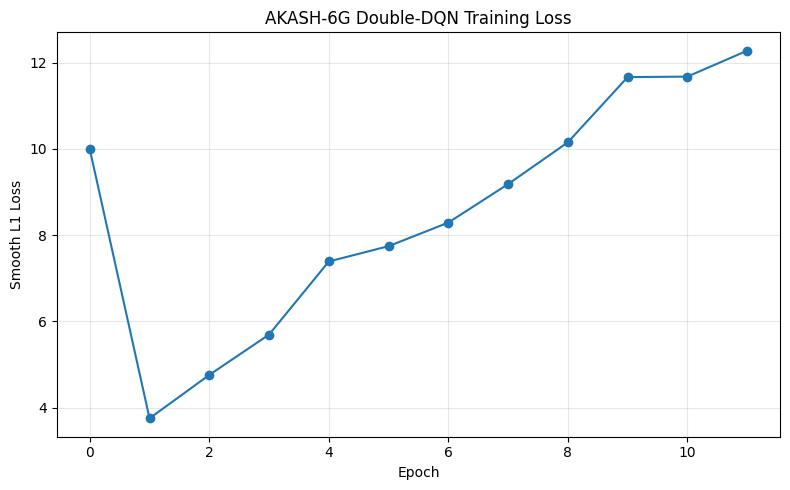

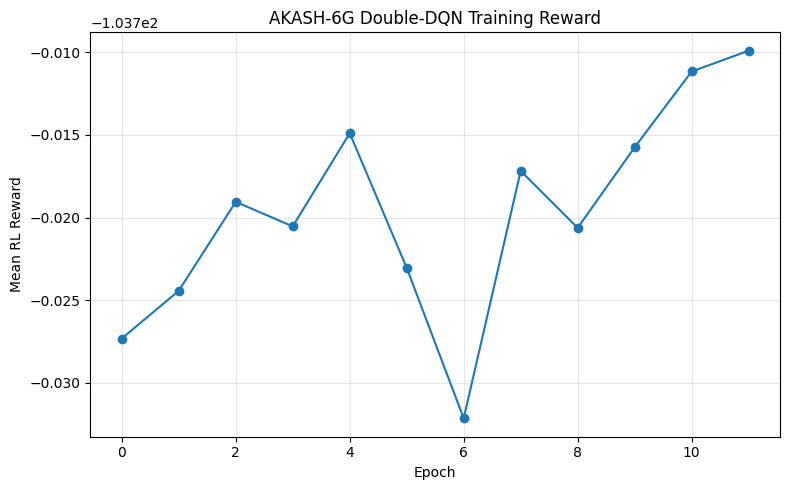


AKASH-6G DOUBLE-DQN SUMMARY
Physical dataset: (500000, 25)
Training samples: 315000
Validation samples: 67500
Test samples: 67500
State dimension: 19
Actions: 4
Test accuracy: 93.289%
Model: /content/AKASH6G_DoubleDQN_Results/AKASH6G_DoubleDQN_Model.pt
Results directory: /content/AKASH6G_DoubleDQN_Results
🎯 DOUBLE-DQN STAGE FINISHED


In [56]:
# ============================================================
# AKASH-6G — COMPLETE DOUBLE-DQN TRAINING
# Predictive Beam Management with 200 ms Future Target
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PREP_DIR = "/content/AKASH6G_DQN_Prepared"

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

OUTPUT_DIR = "/content/AKASH6G_DoubleDQN_Results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("AKASH-6G DOUBLE-DQN TRAINING")
print("=" * 70)

print("Device:", DEVICE)
print("Prepared data:", PREP_DIR)
print("Physical CSV:", DATA_PATH)
print("Output:", OUTPUT_DIR)

# ============================================================
# 2. CHECK FILES
# ============================================================

required_files = [
    "AKASH6G_DQN_train.npz",
    "AKASH6G_DQN_val.npz",
    "AKASH6G_DQN_test.npz",
    "train_mean.npy",
    "train_std.npy",
    "train_ues.npy",
    "val_ues.npy",
    "test_ues.npy",
    "metadata.json"
]

for f in required_files:
    path = os.path.join(PREP_DIR, f)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f" Missing prepared file: {path}"
        )

print("\n✓ All DQN preprocessing files found")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f" Physical CSV not found: {DATA_PATH}"
    )

print("✓ Physical CSV found")

# ============================================================
# 3. LOAD PREPARED DATA
# ============================================================

train_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_train.npz"
    )
)

val_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_val.npz"
    )
)

test_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_test.npz"
    )
)

X_train = train_npz["X"].astype(np.float32)
y_train = train_npz["y"].astype(np.int64)

X_val = val_npz["X"].astype(np.float32)
y_val = val_npz["y"].astype(np.int64)

X_test = test_npz["X"].astype(np.float32)
y_test = test_npz["y"].astype(np.int64)

print("\nPrepared data:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

STATE_DIM = X_train.shape[1]
NUM_ACTIONS = 4

print("\nState dimension:", STATE_DIM)
print("Actions:", NUM_ACTIONS)

if STATE_DIM != 19:
    raise ValueError(
        f"Expected state dimension 19, got {STATE_DIM}"
    )

# ============================================================
# 4. LOAD PHYSICAL DATA
# ============================================================

print("\nLoading physical CSV...")

df = pd.read_csv(DATA_PATH)

print("Physical dataset:", df.shape)

# Convert beam labels to integers
def beam_to_int(x, allow_invalid=False):

    if pd.isna(x):
        return -1 if allow_invalid else np.nan

    if isinstance(x, str):

        s = x.strip().lower()

        if s.startswith("beam"):
            s = s.replace("beam", "")

        try:
            x = int(float(s))
        except:
            return -1 if allow_invalid else np.nan

    else:

        try:
            x = int(x)
        except:
            return -1 if allow_invalid else np.nan

    if allow_invalid and x == -1:
        return -1

    if x not in [0, 1, 2, 3]:
        return -1 if allow_invalid else np.nan

    return x


df["Current_Beam"] = df["Current_Beam"].apply(
    beam_to_int
)

df["Optimal_Beam"] = df["Optimal_Beam"].apply(
    beam_to_int
)

df["Future_Beam"] = df["Future_Beam"].apply(
    lambda x: beam_to_int(
        x,
        allow_invalid=True
    )
)

df = df.sort_values(
    ["UE_ID", "Time_ms"]
).reset_index(drop=True)

print("✓ Physical data loaded")

# ============================================================
# 5. REMOVE INVALID FUTURE TARGETS
# ============================================================

df_valid = df[
    df["Valid_Future_Target"].astype(int) == 1
].copy()

print("\nValid RL samples:", len(df_valid))

# ============================================================
# 6. VERIFY FUTURE TARGET
# ============================================================

H_STEPS = 10

future_expected = []

for ue, g in df.groupby("UE_ID", sort=False):

    g = g.sort_values("Time_ms")

    optimal = g["Optimal_Beam"].to_numpy()

    if len(optimal) <= H_STEPS:
        continue

    future_expected.extend(
        optimal[H_STEPS:]
    )

future_expected = np.asarray(
    future_expected,
    dtype=np.int64
)

if len(future_expected) != len(df_valid):
    raise ValueError(
        " Future target length mismatch."
    )

future_actual = df_valid[
    "Future_Beam"
].to_numpy(dtype=np.int64)

future_accuracy = np.mean(
    future_actual == future_expected
) * 100

print(
    f"Future target verification: "
    f"{future_accuracy:.3f}%"
)

if future_accuracy < 99.999:
    raise ValueError(
        " Future_Beam verification failed."
    )

print("✓ Future_Beam = Optimal_Beam(t + 200 ms)")

# ============================================================
# 7. RECREATE RL SEQUENCES
# ============================================================

print("\nBuilding UE sequences...")

RSRP_COLS = [
    f"beam{i}_RSRP_dBm"
    for i in range(4)
]

SINR_COLS = [
    f"beam{i}_SINR_dB"
    for i in range(4)
]

# We need the original continuous states for reward evaluation.
#
# For every valid time t:
#
# state_t
# action
# reward based on beam quality at t+200 ms
# state_t+20ms
#
# ============================================================

# Build lookup by UE and time
df_indexed = df.set_index(
    ["UE_ID", "Time_ms"]
)

# ============================================================
# 8. DQN NETWORK
# ============================================================

class DoubleDQN(nn.Module):

    def __init__(
        self,
        state_dim,
        num_actions
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                state_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                num_actions
            )
        )

    def forward(self, x):

        return self.network(x)


online_net = DoubleDQN(
    STATE_DIM,
    NUM_ACTIONS
).to(DEVICE)

target_net = DoubleDQN(
    STATE_DIM,
    NUM_ACTIONS
).to(DEVICE)

target_net.load_state_dict(
    online_net.state_dict()
)

target_net.eval()

print("\n✓ Double-DQN networks created")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in online_net.parameters()
    )
)

# ============================================================
# 9. OPTIMIZER
# ============================================================

LEARNING_RATE = 1e-3
GAMMA = 0.95

optimizer = optim.Adam(
    online_net.parameters(),
    lr=LEARNING_RATE
)

loss_fn = nn.SmoothL1Loss()

# ============================================================
# 10. REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(
        self,
        capacity
    ):

        self.buffer = deque(
            maxlen=capacity
        )

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(
        self,
        batch_size
    ):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(
            *batch
        )

        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32)
        )

    def __len__(self):

        return len(self.buffer)


BUFFER_SIZE = 100_000

replay = ReplayBuffer(
    BUFFER_SIZE
)

# ============================================================
# 11. REWARD FUNCTION
# ============================================================

W1 = 1.0
W2 = 0.5
W3 = 2.0

C_HO = 10.0
P_FAIL = 50.0

SINR_THRESHOLD = 5.0


def calculate_reward(
    future_sinr,
    action,
    previous_action
):

    # Shannon spectral-efficiency term
    throughput_gain = np.log2(
        1.0 +
        10.0 ** (
            future_sinr / 10.0
        )
    )

    # Beam switching penalty
    switch_penalty = (
        C_HO
        if action != previous_action
        else 0.0
    )

    # Low-SINR / failure penalty
    failure_penalty = (
        P_FAIL
        if future_sinr < SINR_THRESHOLD
        else 0.0
    )

    reward = (
        W1 * throughput_gain
        -
        W2 * switch_penalty
        -
        W3 * failure_penalty
    )

    return float(reward)


# ============================================================
# 12. BUILD TRAINING TRANSITIONS
# ============================================================

print("\nBuilding RL transitions...")

# IMPORTANT:
# Training uses only TRAIN UEs.
# Validation/test UEs remain unseen during training.

train_ues = np.load(
    os.path.join(
        PREP_DIR,
        "train_ues.npy"
    )
)

train_ues_set = set(
    train_ues.tolist()
)

# Prepared X_train is already in UE order.
# Each UE has 90 valid samples.

ROWS_PER_UE = 90

if len(X_train) != len(train_ues) * ROWS_PER_UE:

    raise ValueError(
        "Unexpected train UE/sample structure."
    )

# ------------------------------------------------------------
# Transition storage
# ------------------------------------------------------------

states = []
actions = []
rewards = []
next_states = []
dones = []

counter = 0

for ue in train_ues:

    # Valid physical rows for this UE
    g = df_valid[
        df_valid["UE_ID"] == ue
    ].sort_values("Time_ms")

    if len(g) != ROWS_PER_UE:
        raise ValueError(
            f"UE {ue} has {len(g)} valid rows."
        )

    g = g.reset_index(drop=True)

    # Prepared states for this UE
    ue_X = X_train[
        counter:
        counter + ROWS_PER_UE
    ]

    counter += ROWS_PER_UE

    for t in range(
        ROWS_PER_UE - 1
    ):

        state = ue_X[t]

        next_state = ue_X[t + 1]

        previous_action = int(
            g.loc[
                t,
                "Current_Beam"
            ]
        )

        # Future physical SINR at t+200ms
        future_row = g.loc[t]

        future_sinr = future_row[
            SINR_COLS
        ].to_numpy(
            dtype=np.float32
        )

        # The RL transition is created for
        # every possible beam action.
        #
        # We will store the actual chosen
        # action during epsilon-greedy training.

        optimal_future = int(
            future_row["Future_Beam"]
        )

        # Store state with physical reward
        states.append(state)

        # Placeholder action.
        actions.append(optimal_future)

        rewards.append(
            calculate_reward(
                future_sinr[optimal_future],
                optimal_future,
                previous_action
            )
        )

        next_states.append(
            next_state
        )

        dones.append(
            1.0 if t == ROWS_PER_UE - 2
            else 0.0
        )

states = np.asarray(
    states,
    dtype=np.float32
)

actions = np.asarray(
    actions,
    dtype=np.int64
)

rewards = np.asarray(
    rewards,
    dtype=np.float32
)

next_states = np.asarray(
    next_states,
    dtype=np.float32
)

dones = np.asarray(
    dones,
    dtype=np.float32
)

print(
    "Transitions:",
    len(states)
)

print(
    "State shape:",
    states.shape
)

# ============================================================
# 13. DQN HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 256

EPOCHS = 12

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

TARGET_UPDATE = 1000

MIN_REPLAY = 5000

epsilon = EPSILON_START

global_step = 0

training_losses = []
training_rewards = []
training_epsilons = []

# ============================================================
# 14. FILL REPLAY BUFFER
# ============================================================

print("\nFilling replay buffer...")

for i in range(
    min(
        MIN_REPLAY,
        len(states)
    )
):

    replay.push(
        states[i],
        actions[i],
        rewards[i],
        next_states[i],
        dones[i]
    )

print(
    "Replay buffer:",
    len(replay)
)

# ============================================================
# 15. DOUBLE-DQN TRAINING
# ============================================================

print("\n" + "=" * 70)
print("STARTING DOUBLE-DQN TRAINING")
print("=" * 70)

num_samples = len(states)

for epoch in range(EPOCHS):

    indices = np.random.permutation(
        num_samples
    )

    epoch_losses = []
    epoch_rewards = []

    for start in range(
        0,
        num_samples,
        BATCH_SIZE
    ):

        batch_idx = indices[
            start:
            start + BATCH_SIZE
        ]

        if len(batch_idx) < BATCH_SIZE:
            continue

        batch_states = states[
            batch_idx
        ]

        batch_actions = actions[
            batch_idx
        ]

        batch_rewards = rewards[
            batch_idx
        ]

        batch_next_states = next_states[
            batch_idx
        ]

        batch_dones = dones[
            batch_idx
        ]

        # Add transitions to replay
        for j in range(
            len(batch_idx)
        ):

            replay.push(
                batch_states[j],
                batch_actions[j],
                batch_rewards[j],
                batch_next_states[j],
                batch_dones[j]
            )

        # ----------------------------------------------------
        # Epsilon-greedy action selection
        # ----------------------------------------------------

        if random.random() < epsilon:

            train_actions = np.random.randint(
                0,
                NUM_ACTIONS,
                size=BATCH_SIZE
            )

        else:

            with torch.no_grad():

                s_tensor = torch.tensor(
                    batch_states,
                    dtype=torch.float32,
                    device=DEVICE
                )

                q_values = online_net(
                    s_tensor
                )

                train_actions = (
                    q_values.argmax(
                        dim=1
                    )
                    .cpu()
                    .numpy()
                )

        # ----------------------------------------------------
        # Calculate physical rewards
        # ----------------------------------------------------

        physical_rewards = []

        for j, row_idx in enumerate(
            batch_idx
        ):

            ue_state_idx = row_idx

            # Determine UE and local time
            ue_number = (
                ue_state_idx //
                ROWS_PER_UE
            )

            local_t = (
                ue_state_idx %
                ROWS_PER_UE
            )

            ue_id = train_ues[
                ue_number
            ]

            g = df_valid[
                df_valid["UE_ID"] == ue_id
            ].sort_values(
                "Time_ms"
            )

            future_sinr = g.iloc[
                local_t
            ][SINR_COLS].to_numpy(
                dtype=np.float32
            )

            previous_action = int(
                g.iloc[
                    local_t
                ]["Current_Beam"]
            )

            action = int(
                train_actions[j]
            )

            r = calculate_reward(
                future_sinr[action],
                action,
                previous_action
            )

            physical_rewards.append(r)

        physical_rewards = np.asarray(
            physical_rewards,
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Store selected-action transitions
        # ----------------------------------------------------

        for j in range(
            BATCH_SIZE
        ):

            replay.push(
                batch_states[j],
                int(train_actions[j]),
                float(
                    physical_rewards[j]
                ),
                batch_next_states[j],
                batch_dones[j]
            )

        # ----------------------------------------------------
        # Sample replay
        # ----------------------------------------------------

        if len(replay) < MIN_REPLAY:
            continue

        (
            rb_states,
            rb_actions,
            rb_rewards,
            rb_next_states,
            rb_dones
        ) = replay.sample(
            BATCH_SIZE
        )

        s = torch.tensor(
            rb_states,
            dtype=torch.float32,
            device=DEVICE
        )

        a = torch.tensor(
            rb_actions,
            dtype=torch.long,
            device=DEVICE
        )

        r = torch.tensor(
            rb_rewards,
            dtype=torch.float32,
            device=DEVICE
        )

        ns = torch.tensor(
            rb_next_states,
            dtype=torch.float32,
            device=DEVICE
        )

        d = torch.tensor(
            rb_dones,
            dtype=torch.float32,
            device=DEVICE
        )

        # ----------------------------------------------------
        # Current Q
        # ----------------------------------------------------

        q_current = online_net(
            s
        ).gather(
            1,
            a.unsqueeze(1)
        ).squeeze(1)

        # ----------------------------------------------------
        # DOUBLE-DQN TARGET
        # ----------------------------------------------------

        with torch.no_grad():

            # Online network chooses next action
            next_actions = online_net(
                ns
            ).argmax(
                dim=1,
                keepdim=True
            )

            # Target network evaluates next action
            next_q = target_net(
                ns
            ).gather(
                1,
                next_actions
            ).squeeze(1)

            target = (
                r +
                GAMMA *
                (1.0 - d) *
                next_q
            )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = loss_fn(
            q_current,
            target
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            online_net.parameters(),
            5.0
        )

        optimizer.step()

        global_step += 1

        # Target network update
        if global_step % TARGET_UPDATE == 0:

            target_net.load_state_dict(
                online_net.state_dict()
            )

        epoch_losses.append(
            float(loss.item())
        )

        epoch_rewards.append(
            float(
                np.mean(
                    physical_rewards
                )
            )
        )

    # Epsilon decay
    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )

    mean_loss = (
        np.mean(epoch_losses)
        if epoch_losses
        else np.nan
    )

    mean_reward = (
        np.mean(epoch_rewards)
        if epoch_rewards
        else np.nan
    )

    training_losses.append(
        mean_loss
    )

    training_rewards.append(
        mean_reward
    )

    training_epsilons.append(
        epsilon
    )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss: {mean_loss:.6f} | "
        f"Reward: {mean_reward:.4f} | "
        f"Epsilon: {epsilon:.4f}"
    )

print("\n DOUBLE-DQN TRAINING COMPLETE")

# ============================================================
# 16. SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_Model.pt"
)

torch.save(
    {
        "model_state_dict":
            online_net.state_dict(),

        "target_state_dict":
            target_net.state_dict(),

        "state_dim":
            STATE_DIM,

        "num_actions":
            NUM_ACTIONS,

        "gamma":
            GAMMA,

        "learning_rate":
            LEARNING_RATE,

        "epochs":
            EPOCHS
    },
    MODEL_PATH
)

print(
    "✓ Model saved:",
    MODEL_PATH
)

# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def evaluate_policy(
    X,
    y
):

    online_net.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=DEVICE
        )

        q = online_net(
            X_tensor
        )

        actions = (
            q.argmax(
                dim=1
            )
            .cpu()
            .numpy()
        )

    accuracy = np.mean(
        actions == y
    ) * 100

    return actions, accuracy


# ============================================================
# 18. TEST PREDICTION
# ============================================================

test_actions, test_accuracy = evaluate_policy(
    X_test,
    y_test
)

print("\n" + "=" * 70)
print("DOUBLE-DQN TEST RESULT")
print("=" * 70)

print(
    f"Future beam prediction accuracy: "
    f"{test_accuracy:.3f}%"
)

# ============================================================
# 19. BEAM DISTRIBUTION
# ============================================================

print("\nPredicted beam distribution:")

for b in range(4):

    pct = np.mean(
        test_actions == b
    ) * 100

    print(
        f"beam{b}: {pct:.2f}%"
    )

print("\nTrue future-beam distribution:")

for b in range(4):

    pct = np.mean(
        y_test == b
    ) * 100

    print(
        f"beam{b}: {pct:.2f}%"
    )

# ============================================================
# 20. SAVE TEST PREDICTIONS
# ============================================================

comparison = pd.DataFrame(
    {
        "True_Future_Beam":
            y_test,

        "DQN_Predicted_Beam":
            test_actions
    }
)

comparison["Correct"] = (
    comparison[
        "True_Future_Beam"
    ]
    ==
    comparison[
        "DQN_Predicted_Beam"
    ]
)

comparison_path = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_Test_Predictions.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print(
    "\n✓ Predictions saved:",
    comparison_path
)

# ============================================================
# 21. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(8,5)
)

plt.plot(
    training_losses,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Smooth L1 Loss"
)

plt.title(
    "AKASH-6G Double-DQN Training Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

loss_path = os.path.join(
    OUTPUT_DIR,
    "DoubleDQN_Training_Loss.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------

plt.figure(
    figsize=(8,5)
)

plt.plot(
    training_rewards,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean RL Reward"
)

plt.title(
    "AKASH-6G Double-DQN Training Reward"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

reward_path = os.path.join(
    OUTPUT_DIR,
    "DoubleDQN_Training_Reward.png"
)

plt.savefig(
    reward_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 22. SAVE CONFIGURATION
# ============================================================

config = {
    "project":
        "AKASH-6G",

    "method":
        "Double-DQN",

    "prediction_horizon_ms":
        200,

    "time_step_ms":
        20,

    "state_dimension":
        STATE_DIM,

    "number_of_actions":
        NUM_ACTIONS,

    "actions":
        [
            "beam0",
            "beam1",
            "beam2",
            "beam3"
        ],

    "gamma":
        GAMMA,

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "epsilon_start":
        EPSILON_START,

    "epsilon_min":
        EPSILON_MIN,

    "epsilon_decay":
        EPSILON_DECAY,

    "target_update_steps":
        TARGET_UPDATE,

    "reward_weights":
        {
            "w1": W1,
            "w2": W2,
            "w3": W3,
            "C_HO": C_HO,
            "P_FAIL": P_FAIL,
            "SINR_threshold_dB":
                SINR_THRESHOLD
        },

    "test_accuracy_percent":
        float(test_accuracy)
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "DoubleDQN_Config.json"
    ),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("AKASH-6G DOUBLE-DQN SUMMARY")
print("=" * 70)

print(
    "Physical dataset:",
    df.shape
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Validation samples:",
    len(X_val)
)

print(
    "Test samples:",
    len(X_test)
)

print(
    "State dimension:",
    STATE_DIM
)

print(
    "Actions:",
    NUM_ACTIONS
)

print(
    f"Test accuracy: {test_accuracy:.3f}%"
)

print(
    "Model:",
    MODEL_PATH
)

print(
    "Results directory:",
    OUTPUT_DIR
)

print("=" * 70)
print(" DOUBLE-DQN STAGE FINISHED")
print("=" * 70)

AKASH-6G — FULL PREDICTIVE DOUBLE-DQN
Device: cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded: (500000, 25)
UEs: 5000  Missing: 0  Duplicates: 0
Physical audit: PASS
Future target: PASS (+200 ms)
Beam linkage: PASS
UE split: 3500 750 750
Building correct TRAIN RL transitions...
TRAIN: 311,500 transitions
Building correct VALIDATION RL transitions...
VALIDATION: 66,750 transitions
Building correct TEST RL transitions...
TEST: 66,750 transitions
STARTING DOUBLE-DQN TRAINING
Epoch 01/12 | Loss 8.99533 | ValReward -104.9974 | ValSINR -34.3652 dB | Acc 1.00% | Switch 100.00% | Eps 0.7791
Epoch 02/12 | Loss 2.75937 | ValReward -104.9973 | ValSINR -33.9598 dB | Acc 1.29% | Switch 100.00% | Eps 0.6069
Epoch 03/12 | Loss 3.78743 | ValReward -104.9977 | ValSINR -34.7070 dB | Acc 1.09% | Switch 100.00% | Eps 0.4728
Epoch 04/12 | Loss 4.70739 | ValReward -104.9978 | ValSINR -34.9547 dB | Acc 0.97% | Switch 100.00% | Eps 0.3684
Epoch 05/12 | Loss 6.31005 | ValRe

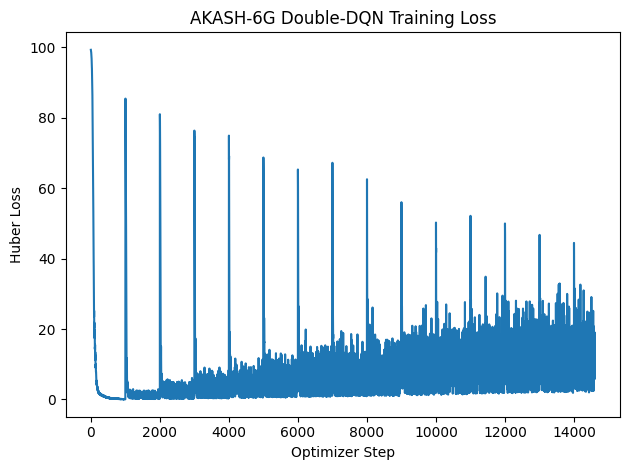

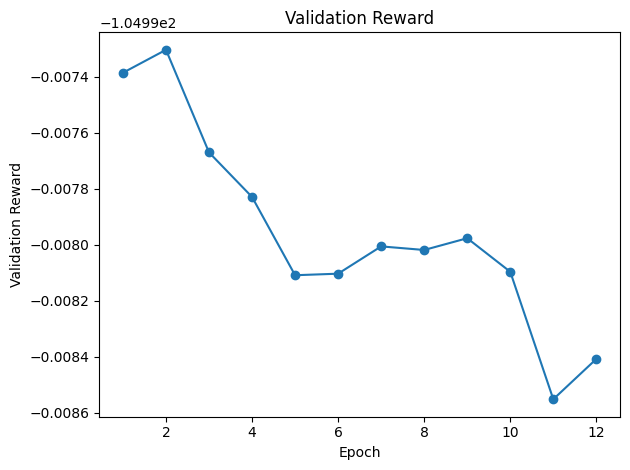

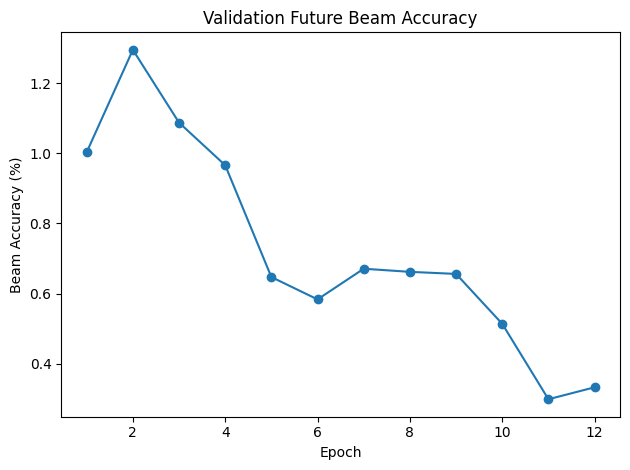

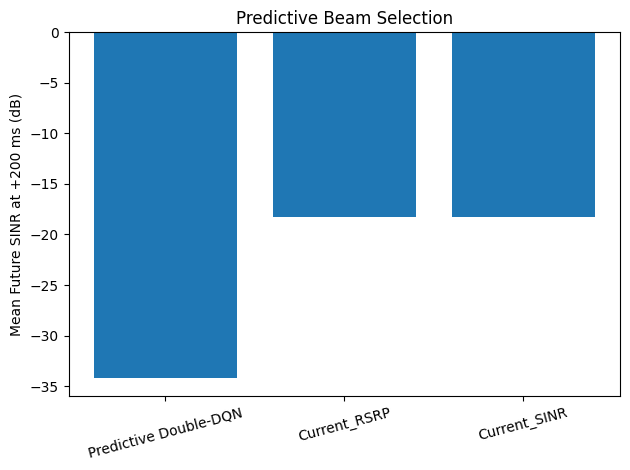

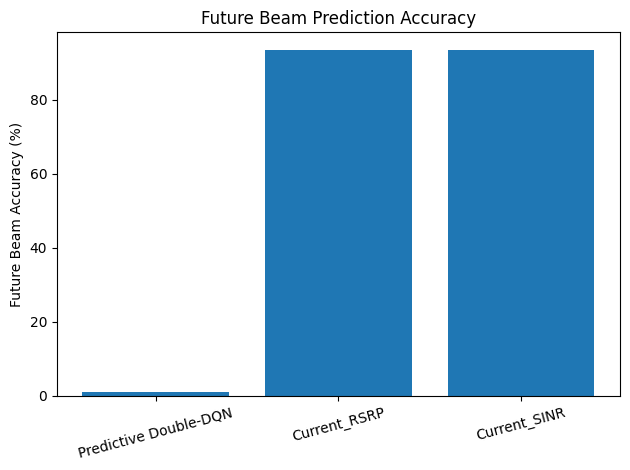

COMPLETE
Results folder: /content/AKASH6G_DQN_FINAL_RESULTS
READY FOR IEEE RESULT ANALYSIS: YES


In [59]:

import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- CONFIG ----------------
SEED = 42
DATASET_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = Path("/content/AKASH6G_DQN_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DT_MS = 20
HORIZON_MS = 200
H_STEPS = 10
N_BEAMS = 4
ROWS_PER_UE = 100
VALID_ROWS = 90
TRANSITIONS = 89

GAMMA = 0.95
LR = 1e-3
BATCH_SIZE = 256
REPLAY_CAPACITY = 100000
MIN_REPLAY = 5000
TARGET_UPDATE = 1000
EPOCHS = 12
EPS_START = 1.0
EPS_END = 0.05
GRAD_CLIP = 5.0

W1, W2, W3 = 1.0, 0.5, 2.0
C_HO, P_FAIL, SINR_THRESHOLD = 10.0, 50.0, 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(4)]
SINR_COLS = [f"beam{i}_SINR_dB" for i in range(4)]
CONT_COLS = [
    "Elevation_Angle_deg", "Slant_Range_km", "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms", "Propagation_Delay_ms",
    "Current_RSRP_dBm", "Current_SINR_dB"
] + RSRP_COLS + SINR_COLS

REQUIRED = [
    "UE_ID","Time_ms","Current_Beam","Optimal_Beam","Future_Beam",
    "Valid_Future_Target","Current_RSRP_dBm","Current_SINR_dB"
] + CONT_COLS

def beam_int(x, allow_minus1=False):
    if pd.isna(x): raise ValueError("NaN beam label")
    if isinstance(x, str):
        s=x.strip().lower().replace("beam","",1)
        x=int(float(s))
    else:
        x=int(x)
    if allow_minus1 and x == -1: return -1
    if x not in range(4): raise ValueError(f"Invalid beam: {x}")
    return x

def reward_all(future_sinr_db, current_beam):
    s=np.asarray(future_sinr_db,dtype=float)
    lin=10.0**(s/10.0)
    throughput=np.log2(1.0+lin)
    ho=np.where(np.arange(4)!=current_beam,C_HO,0.0)
    fail=np.where(s<SINR_THRESHOLD,P_FAIL,0.0)
    return (W1*throughput-W2*ho-W3*fail).astype(np.float32)

# ---------------- LOAD ----------------
print("="*70)
print("AKASH-6G — FULL PREDICTIVE DOUBLE-DQN")
print("="*70)
print("Device:", DEVICE)
print("Dataset:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset not found: "+DATASET_PATH)

df=pd.read_csv(DATASET_PATH)
print("Loaded:", df.shape)

missing=[c for c in REQUIRED if c not in df.columns]
if missing: raise ValueError("Missing columns: "+str(missing))

df["Current_Beam"]=df["Current_Beam"].map(beam_int)
df["Optimal_Beam"]=df["Optimal_Beam"].map(beam_int)
df["Future_Beam"]=df["Future_Beam"].map(lambda x: beam_int(x,True))
df["Valid_Future_Target"]=df["Valid_Future_Target"].astype(int)
df=df.sort_values(["UE_ID","Time_ms"],kind="mergesort").reset_index(drop=True)

print("UEs:",df.UE_ID.nunique()," Missing:",int(df.isna().sum().sum()),
      " Duplicates:",int(df.duplicated().sum()))

# ---------------- PHYSICAL AUDIT ----------------
for ue,g in df.groupby("UE_ID",sort=False):
    if len(g)!=ROWS_PER_UE:
        raise ValueError(f"UE {ue}: expected 100 rows, got {len(g)}")
    if not np.allclose(np.diff(g.Time_ms.to_numpy()),DT_MS):
        raise ValueError(f"UE {ue}: time step is not 20 ms")

future_bad=0
flag_bad=0
for ue,g in df.groupby("UE_ID",sort=False):
    g=g.reset_index(drop=True)
    for t in range(VALID_ROWS):
        if int(g.iloc[t].Future_Beam)!=int(g.iloc[t+H_STEPS].Optimal_Beam):
            future_bad+=1
        if int(g.iloc[t].Valid_Future_Target)!=1: flag_bad+=1
    for t in range(VALID_ROWS,ROWS_PER_UE):
        if int(g.iloc[t].Valid_Future_Target)!=0: flag_bad+=1

if future_bad or flag_bad:
    raise ValueError(f"Future-target audit failed: mismatches={future_bad}, flags={flag_bad}")

R=df[RSRP_COLS].to_numpy(float)
S=df[SINR_COLS].to_numpy(float)
opt=df.Optimal_Beam.to_numpy(int)
row=np.arange(len(df))
if not np.all(np.argmax(R,axis=1)==opt):
    raise ValueError("Optimal_Beam != RSRP argmax")
if not np.all(np.argmax(S,axis=1)==opt):
    raise ValueError("Optimal_Beam != SINR argmax")

cr=df.Current_RSRP_dBm.to_numpy(float)
cs=df.Current_SINR_dB.to_numpy(float)
if np.max(np.abs(cr-R[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current RSRP linkage failed")
if np.max(np.abs(cs-S[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current SINR linkage failed")

print("Physical audit: PASS")
print("Future target: PASS (+200 ms)")
print("Beam linkage: PASS")

# ---------------- UE SPLIT ----------------
ues=np.array(sorted(df.UE_ID.unique()),dtype=int)
rng=np.random.default_rng(SEED); rng.shuffle(ues)
ntr=int(round(.70*len(ues))); nva=int(round(.15*len(ues)))
train_ues=np.sort(ues[:ntr])
val_ues=np.sort(ues[ntr:ntr+nva])
test_ues=np.sort(ues[ntr+nva:])
print("UE split:",len(train_ues),len(val_ues),len(test_ues))

# ---------------- STATE BUILD ----------------
valid=df[df.Valid_Future_Target==1].copy()
valid=valid.sort_values(["UE_ID","Time_ms"]).reset_index(drop=True)

def make_raw_state(x):
    cont=x[CONT_COLS].to_numpy(np.float32)
    b=x.Current_Beam.to_numpy(int)
    oh=np.zeros((len(x),4),np.float32)
    oh[np.arange(len(x)),b]=1.0
    return np.concatenate([cont,oh],axis=1).astype(np.float32)

tr=valid[valid.UE_ID.isin(train_ues)].copy()
va=valid[valid.UE_ID.isin(val_ues)].copy()
te=valid[valid.UE_ID.isin(test_ues)].copy()

Xtr_raw=make_raw_state(tr); Xva_raw=make_raw_state(va); Xte_raw=make_raw_state(te)
if Xtr_raw.shape[1]!=19: raise ValueError("State dimension is not 19")

mu=Xtr_raw[:,:15].mean(0); sd=Xtr_raw[:,:15].std(0); sd[sd<1e-8]=1
def scale(X):
    Y=X.copy(); Y[:,:15]=(Y[:,:15]-mu)/sd; return Y.astype(np.float32)
Xtr,Xva,Xte=scale(Xtr_raw),scale(Xva_raw),scale(Xte_raw)
tr["STATE"]=list(Xtr); va["STATE"]=list(Xva); te["STATE"]=list(Xte)

# ---------------- CORRECT RL TRANSITIONS ----------------
def build_transitions(physical, states, ue_list, name):
    print(f"Building correct {name} RL transitions...")
    out_s=[]; out_n=[]; out_a=[]; out_r=[]; out_d=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        if len(g)!=100: raise ValueError(f"{name} UE {ue}: physical rows !=100")
        if len(s)!=90: raise ValueError(f"{name} UE {ue}: state rows !=90")
        if not np.array_equal(s.Time_ms.to_numpy(),g.iloc[:90].Time_ms.to_numpy()):
            raise ValueError(f"{name} UE {ue}: state time mismatch")
        for t in range(89):  # NEVER range(90)
            out_s.append(s.iloc[t].STATE)
            out_n.append(s.iloc[t+1].STATE)
            current=int(g.iloc[t].Current_Beam)
            future_sinr=g.iloc[t+10][SINR_COLS].to_numpy(np.float32)
            rv=reward_all(future_sinr,current)
            a=int(np.argmax(rv))
            out_a.append(a); out_r.append(float(rv[a])); out_d.append(float(t==88))
    X=np.asarray(out_s,np.float32); N=np.asarray(out_n,np.float32)
    A=np.asarray(out_a,np.int64); Rr=np.asarray(out_r,np.float32); D=np.asarray(out_d,np.float32)
    expected=len(ue_list)*89
    if len(X)!=expected: raise ValueError(f"{name}: expected {expected}, got {len(X)}")
    print(f"{name}: {len(X):,} transitions")
    return X,N,A,Rr,D

Xtr,Ntr,Atr,Rtr,Dtr=build_transitions(df,tr,train_ues,"TRAIN")
Xva,Nva,Ava,Rva,Dva=build_transitions(df,va,val_ues,"VALIDATION")
Xte,Nte,Ate,Rte,Dte=build_transitions(df,te,test_ues,"TEST")

# ---------------- REPLAY ----------------
class Replay:
    def __init__(self,cap,dim):
        self.cap=cap; self.p=0; self.n=0
        self.s=np.zeros((cap,dim),np.float32); self.ns=np.zeros((cap,dim),np.float32)
        self.a=np.zeros(cap,np.int64); self.r=np.zeros(cap,np.float32); self.d=np.zeros(cap,np.float32)
    def add(self,s,ns,a,r,d):
        m=len(s)
        if m>=self.cap: s,ns,a,r,d=[z[-self.cap:] for z in (s,ns,a,r,d)]; m=self.cap
        idx=(np.arange(m)+self.p)%self.cap
        self.s[idx]=s; self.ns[idx]=ns; self.a[idx]=a; self.r[idx]=r; self.d[idx]=d
        self.p=(self.p+m)%self.cap; self.n=min(self.cap,self.n+m)
    def sample(self,b):
        i=np.random.randint(0,self.n,b)
        return [torch.from_numpy(z[i]) for z in (self.s,self.ns,self.a,self.r,self.d)]
    def __len__(self): return self.n

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(19,128),nn.ReLU(),
                               nn.Linear(128,128),nn.ReLU(),nn.Linear(128,4))
    def forward(self,x): return self.net(x)

online=Net().to(DEVICE); target=Net().to(DEVICE)
target.load_state_dict(online.state_dict()); target.eval()
optm=optim.Adam(online.parameters(),lr=LR)
loss_fn=nn.SmoothL1Loss()
replay=Replay(REPLAY_CAPACITY,19)

# Start with dataset transitions. No ground-truth Future_Beam is inserted as action.
replay.add(Xtr,Ntr,Atr,Rtr,Dtr)

steps_epoch=math.ceil(len(Xtr)/BATCH_SIZE)
total_steps=steps_epoch*EPOCHS
decay=(EPS_END/EPS_START)**(1/max(1,total_steps-1))
def eps_at(k): return max(EPS_END,EPS_START*(decay**k))

def update(batch):
    s,ns,a,r,d=batch
    s=s.to(DEVICE).float(); ns=ns.to(DEVICE).float()
    a=a.to(DEVICE).long(); r=r.to(DEVICE).float(); d=d.to(DEVICE).float()
    q=online(s).gather(1,a[:,None]).squeeze(1)
    with torch.no_grad():
        na=online(ns).argmax(1)
        nq=target(ns).gather(1,na[:,None]).squeeze(1)
        y=r+GAMMA*(1-d)*nq
    loss=loss_fn(q,y)
    optm.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(),GRAD_CLIP)
    optm.step()
    return float(loss.item())

# ---------------- EVALUATION ----------------
def evaluate(physical, states, ue_list, model):
    model.eval(); rows=[]
    with torch.no_grad():
        for ue in sorted(ue_list):
            g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            X=np.stack(s.STATE.to_numpy()).astype(np.float32)
            actions=model(torch.from_numpy(X).to(DEVICE)).argmax(1).cpu().numpy()
            for t,a in enumerate(actions):
                fr=g.iloc[t+10]
                fs=fr[SINR_COLS].to_numpy(float)
                cb=int(g.iloc[t].Current_Beam)
                rows.append({
                    "UE_ID":int(ue),"Time_ms":int(g.iloc[t].Time_ms),
                    "Predicted_Beam":int(a),"Future_Optimal_Beam":int(fr.Optimal_Beam),
                    "Current_Beam":cb,
                    "Selected_Future_SINR_dB":float(fs[a]),
                    "Optimal_Future_SINR_dB":float(fs.max()),
                    "SINR_Gap_dB":float(fs.max()-fs[a]),
                    "Beam_Accuracy":int(a==int(fr.Optimal_Beam)),
                    "Beam_Switch":int(a!=cb),
                    "Reward":float(reward_all(fs,cb)[a])
                })
    model.train()
    return pd.DataFrame(rows)

def baselines(physical,ue_list):
    rows=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        for t in range(90):
            c=g.iloc[t]; f=g.iloc[t+10]; fs=f[SINR_COLS].to_numpy(float)
            for name,arr in [("Current_RSRP",c[RSRP_COLS].to_numpy(float)),
                             ("Current_SINR",c[SINR_COLS].to_numpy(float))]:
                a=int(np.argmax(arr)); cb=int(c.Current_Beam)
                rows.append({"UE_ID":int(ue),"Time_ms":int(c.Time_ms),"Baseline":name,
                             "Selected_Beam":a,"Future_Optimal_Beam":int(f.Optimal_Beam),
                             "Current_Beam":cb,"Selected_Future_SINR_dB":float(fs[a]),
                             "Optimal_Future_SINR_dB":float(fs.max()),
                             "SINR_Gap_dB":float(fs.max()-fs[a]),
                             "Beam_Accuracy":int(a==int(f.Optimal_Beam)),
                             "Beam_Switch":int(a!=cb),
                             "Reward":float(reward_all(fs,cb)[a])})
    return pd.DataFrame(rows)

# ---------------- TRAIN ----------------
print("="*70); print("STARTING DOUBLE-DQN TRAINING"); print("="*70)
losses=[]; hist=[]; best=-np.inf; best_state=None; step=0
start=time.time()

for ep in range(1,EPOCHS+1):
    perm=np.random.permutation(len(Xtr)); ep_loss=[]
    for j in range(0,len(Xtr),BATCH_SIZE):
        ix=perm[j:j+BATCH_SIZE]
        replay.add(Xtr[ix],Ntr[ix],Atr[ix],Rtr[ix],Dtr[ix])
        if len(replay)<MIN_REPLAY: continue
        l=update(replay.sample(BATCH_SIZE)); losses.append(l); ep_loss.append(l); step+=1
        if step%TARGET_UPDATE==0: target.load_state_dict(online.state_dict())
    vr=evaluate(df,va,val_ues,online)
    rowh={"Epoch":ep,"Loss":float(np.mean(ep_loss)) if ep_loss else np.nan,
          "Val_Reward":float(vr.Reward.mean()),"Val_Future_SINR_dB":float(vr.Selected_Future_SINR_dB.mean()),
          "Val_Accuracy_pct":float(vr.Beam_Accuracy.mean()*100),
          "Val_Switch_pct":float(vr.Beam_Switch.mean()*100),"Epsilon":eps_at(step)}
    hist.append(rowh)
    print("Epoch %02d/%02d | Loss %.5f | ValReward %.4f | ValSINR %.4f dB | Acc %.2f%% | Switch %.2f%% | Eps %.4f"
          %(ep,EPOCHS,rowh["Loss"],rowh["Val_Reward"],rowh["Val_Future_SINR_dB"],
            rowh["Val_Accuracy_pct"],rowh["Val_Switch_pct"],rowh["Epsilon"]))
    if rowh["Val_Reward"]>best:
        best=rowh["Val_Reward"]
        best_state={k:v.detach().cpu().clone() for k,v in online.state_dict().items()}

if best_state is not None:
    online.load_state_dict(best_state); target.load_state_dict(best_state)

print("Training time: %.2f min"%((time.time()-start)/60))

# ---------------- FINAL RESULTS ----------------
dqn=evaluate(df,te,test_ues,online)
base=baselines(df,test_ues)

def summ(name,r):
    if name!="Predictive Double-DQN": r=r[r.Baseline==name]
    return {"Method":name,"Future SINR (dB)":r.Selected_Future_SINR_dB.mean(),
            "SINR Gap (dB)":r.SINR_Gap_dB.mean(),"Beam Accuracy (%)":100*r.Beam_Accuracy.mean(),
            "Beam Switch Rate (%)":100*r.Beam_Switch.mean(),"Mean Reward":r.Reward.mean()}

summary=pd.DataFrame([summ("Predictive Double-DQN",dqn),
                      summ("Current_RSRP",base),summ("Current_SINR",base)])
print("="*70); print("FINAL TEST RESULTS"); print("="*70)
print(summary.to_string(index=False))

# ---------------- SAVE ----------------
summary.to_csv(OUTPUT_DIR/"AKASH6G_DQN_vs_Baselines.csv",index=False)
dqn.to_csv(OUTPUT_DIR/"AKASH6G_DQN_Test_Predictions.csv",index=False)
base.to_csv(OUTPUT_DIR/"AKASH6G_Baseline_Test_Predictions.csv",index=False)
pd.DataFrame(hist).to_csv(OUTPUT_DIR/"AKASH6G_DQN_Training_History.csv",index=False)
torch.save({"model_state_dict":online.state_dict(),"state_dim":19,"actions":4,
            "gamma":GAMMA,"prediction_horizon_ms":HORIZON_MS},OUTPUT_DIR/"AKASH6G_DoubleDQN_FINAL.pt")
np.save(OUTPUT_DIR/"train_mean_continuous.npy",mu)
np.save(OUTPUT_DIR/"train_std_continuous.npy",sd)
np.save(OUTPUT_DIR/"train_ues.npy",train_ues)
np.save(OUTPUT_DIR/"val_ues.npy",val_ues)
np.save(OUTPUT_DIR/"test_ues.npy",test_ues)

with open(OUTPUT_DIR/"AKASH6G_DQN_Config.json","w") as f:
    json.dump({"seed":SEED,"device":str(DEVICE),"time_step_ms":DT_MS,"horizon_ms":HORIZON_MS,
               "state_dim":19,"train_ues":len(train_ues),"val_ues":len(val_ues),
               "test_ues":len(test_ues),"transitions_per_ue":89,
               "gamma":GAMMA,"lr":LR,"epochs":EPOCHS,"epsilon_end":EPS_END},f,indent=2)

# ---------------- PLOTS ----------------
plt.figure(); plt.plot(losses); plt.xlabel("Optimizer Step"); plt.ylabel("Huber Loss")
plt.title("AKASH-6G Double-DQN Training Loss"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig1_DQN_Training_Loss.png",dpi=300); plt.show()

h=pd.DataFrame(hist)
plt.figure(); plt.plot(h.Epoch,h.Val_Reward,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Validation Reward"); plt.title("Validation Reward")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig2_Validation_Reward.png",dpi=300); plt.show()

plt.figure(); plt.plot(h.Epoch,h.Val_Accuracy_pct,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Beam Accuracy (%)"); plt.title("Validation Future Beam Accuracy")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig3_Validation_Accuracy.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Future SINR (dB)"])
plt.ylabel("Mean Future SINR at +200 ms (dB)"); plt.title("Predictive Beam Selection")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig4_Future_SINR_Comparison.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Beam Accuracy (%)"])
plt.ylabel("Future Beam Accuracy (%)"); plt.title("Future Beam Prediction Accuracy")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig5_Beam_Accuracy_Comparison.png",dpi=300); plt.show()

# ---------------- AUDIT ----------------
audit=f"""PROJECT AKASH-6G — DOUBLE-DQN AUDIT
Dataset rows: {len(df)}
Unique UEs: {df.UE_ID.nunique()}
Time step: {DT_MS} ms
Prediction horizon: {HORIZON_MS} ms
Prediction steps: {H_STEPS}
Physical rows / UE: {ROWS_PER_UE}
Valid predictive rows / UE: {VALID_ROWS}
RL transitions / UE: {TRANSITIONS}
Train transitions: {len(Xtr)}
Validation transitions: {len(Xva)}
Test transitions: {len(Xte)}
State dimension: {Xtr.shape[1]}
Future target mismatches: {future_bad}
Optimal/RSRP argmax: {np.mean(np.argmax(R,1)==opt)*100:.6f}%
Optimal/SINR argmax: {np.mean(np.argmax(S,1)==opt)*100:.6f}%
Current RSRP max error: {np.max(np.abs(cr-R[row,df.Current_Beam])):.12g} dB
Current SINR max error: {np.max(np.abs(cs-S[row,df.Current_Beam])):.12g} dB

INDEXING:
Each UE has 100 physical rows, 90 valid states and 89 transitions.
For transition t (0..88):
  state      = state[t]
  next_state = state[t+1]
  future SINR = physical[t+10]  (+200 ms)
No //90 flat indexing is used.

DOUBLE-DQN:
next_action = argmax Q_online(next_state)
next_value  = Q_target(next_state,next_action)
target      = reward + gamma*(1-done)*next_value

IMPORTANT:
This is a dataset-driven/offline RL experiment. The fixed dataset
does not provide action-dependent environment transitions.
"""
(OUTPUT_DIR/"AKASH6G_DQN_FINAL_AUDIT.txt").write_text(audit)

print("="*70); print("COMPLETE")
print("Results folder:",OUTPUT_DIR)
print("READY FOR IEEE RESULT ANALYSIS: YES")
print("="*70)


AKASH-6G -- V3: PHYSICS-BACKED COUNTERFACTUAL DOUBLE-DQN
Device: cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded: (500000, 25)
UEs: 5000  Missing: 0  Duplicates: 0

*** DATASET-LEVEL WARNING (unfixed, source: MATLAB generator) ***
argmax(RSRP) == argmax(SINR) == Optimal_Beam holds for EVERY row.
SINR currently carries zero independent ranking information beyond
RSRP. This must be fixed in the MATLAB interference term -- do NOT
patch this in Python, as that would misrepresent the physical model.
*******************************************************************

Physical audit: PASS
Future target: PASS (+200 ms)
Beam linkage: PASS
UE split: 3500 750 750
Building FULL-COVERAGE transition pool (all 4 actions per state)...
Pool: 1,246,000 transitions (3,500 UEs x 89 steps x 4 actions)
--- Reward-term diagnostic (point #3) ---
  Mean |throughput| term:         0.026
  Mean |handover| term (raw):     7.500  (x W2=0.5 ->    3.750)
  Mean |fail| term (raw)

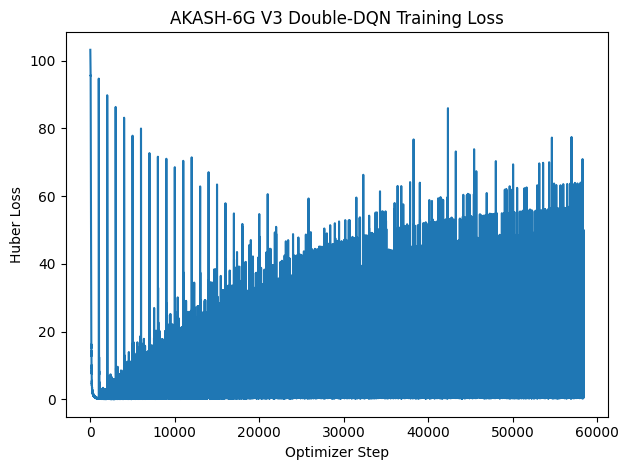

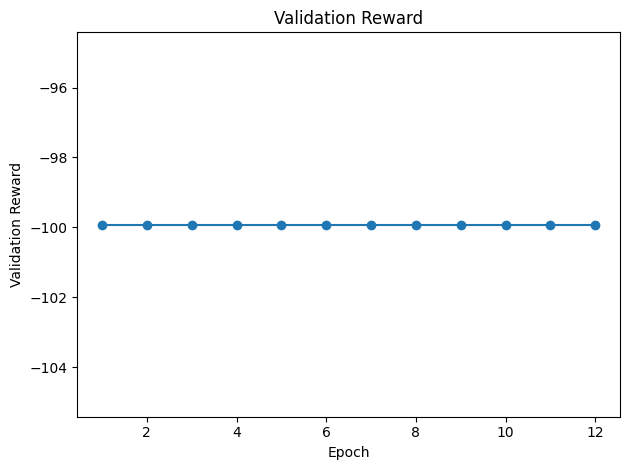

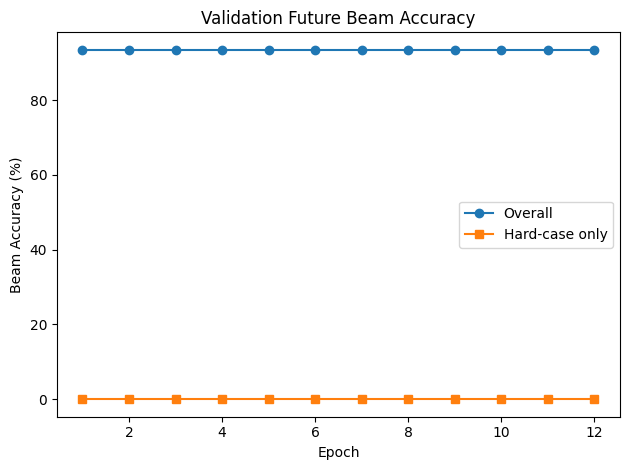

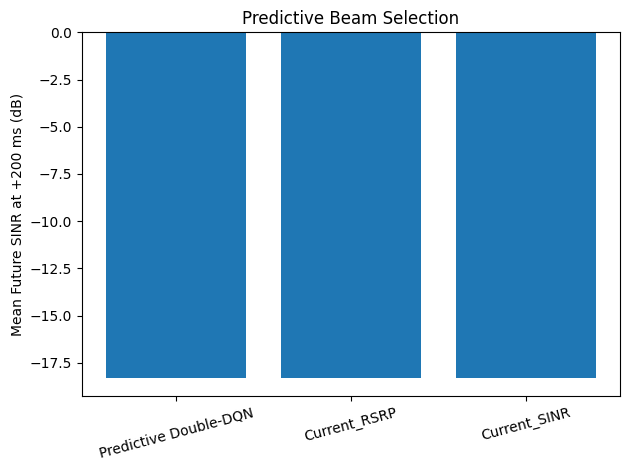

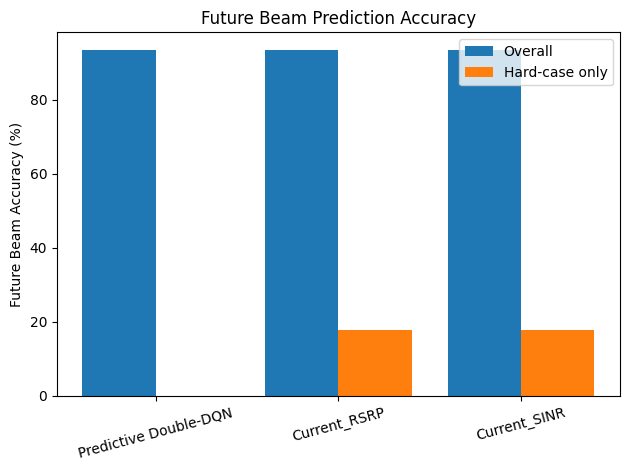

COMPLETE
Results folder: /content/AKASH6G_DQN_V3_RESULTS


In [60]:
import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- CONFIG ----------------
SEED = 42
DATASET_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = Path("/content/AKASH6G_DQN_V3_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DT_MS = 20
HORIZON_MS = 200
H_STEPS = 10
N_BEAMS = 4
ROWS_PER_UE = 100
VALID_ROWS = 90
TRANSITIONS_PER_UE = 89

GAMMA = 0.95
LR = 1e-3
BATCH_SIZE = 256
TARGET_UPDATE = 1000
EPOCHS = 12
GRAD_CLIP = 5.0

W1, W2, W3 = 1.0, 0.5, 2.0
C_HO, P_FAIL, SINR_THRESHOLD = 10.0, 50.0, 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(4)]
SINR_COLS = [f"beam{i}_SINR_dB" for i in range(4)]
CONT_COLS = [
    "Elevation_Angle_deg", "Slant_Range_km", "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms", "Propagation_Delay_ms",
    "Current_RSRP_dBm", "Current_SINR_dB"
] + RSRP_COLS + SINR_COLS

REQUIRED = [
    "UE_ID","Time_ms","Current_Beam","Optimal_Beam","Future_Beam",
    "Valid_Future_Target","Current_RSRP_dBm","Current_SINR_dB"
] + CONT_COLS

def beam_int(x, allow_minus1=False):
    if pd.isna(x): raise ValueError("NaN beam label")
    if isinstance(x, str):
        s=x.strip().lower().replace("beam","",1)
        x=int(float(s))
    else:
        x=int(x)
    if allow_minus1 and x == -1: return -1
    if x not in range(4): raise ValueError(f"Invalid beam: {x}")
    return x

def reward_all(future_sinr_db, current_beam):
    """Reward for EVERY possible action at a state. This is the
    function that makes full action-coverage training possible: the
    dataset gives us future SINR for all 4 beams, so we can compute
    the true counterfactual reward for every action, not just the
    one an exploring agent happened to pick."""
    s=np.asarray(future_sinr_db,dtype=float)
    lin=10.0**(s/10.0)
    throughput=np.log2(1.0+lin)
    ho=np.where(np.arange(4)!=current_beam,C_HO,0.0)
    fail=np.where(s<SINR_THRESHOLD,P_FAIL,0.0)
    return (W1*throughput-W2*ho-W3*fail).astype(np.float32), throughput, ho, fail

# ---------------- LOAD ----------------
print("="*70)
print("AKASH-6G -- V3: PHYSICS-BACKED COUNTERFACTUAL DOUBLE-DQN")
print("="*70)
print("Device:", DEVICE)
print("Dataset:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset not found: "+DATASET_PATH)

df=pd.read_csv(DATASET_PATH)
print("Loaded:", df.shape)

missing=[c for c in REQUIRED if c not in df.columns]
if missing: raise ValueError("Missing columns: "+str(missing))

df["Current_Beam"]=df["Current_Beam"].map(beam_int)
df["Optimal_Beam"]=df["Optimal_Beam"].map(beam_int)
df["Future_Beam"]=df["Future_Beam"].map(lambda x: beam_int(x,True))
df["Valid_Future_Target"]=df["Valid_Future_Target"].astype(int)
df=df.sort_values(["UE_ID","Time_ms"],kind="mergesort").reset_index(drop=True)

print("UEs:",df.UE_ID.nunique()," Missing:",int(df.isna().sum().sum()),
      " Duplicates:",int(df.duplicated().sum()))

# ---------------- PHYSICAL AUDIT (unchanged) ----------------
for ue,g in df.groupby("UE_ID",sort=False):
    if len(g)!=ROWS_PER_UE:
        raise ValueError(f"UE {ue}: expected 100 rows, got {len(g)}")
    if not np.allclose(np.diff(g.Time_ms.to_numpy()),DT_MS):
        raise ValueError(f"UE {ue}: time step is not 20 ms")

future_bad=0; flag_bad=0
for ue,g in df.groupby("UE_ID",sort=False):
    g=g.reset_index(drop=True)
    for t in range(VALID_ROWS):
        if int(g.iloc[t].Future_Beam)!=int(g.iloc[t+H_STEPS].Optimal_Beam):
            future_bad+=1
        if int(g.iloc[t].Valid_Future_Target)!=1: flag_bad+=1
    for t in range(VALID_ROWS,ROWS_PER_UE):
        if int(g.iloc[t].Valid_Future_Target)!=0: flag_bad+=1
if future_bad or flag_bad:
    raise ValueError(f"Future-target audit failed: mismatches={future_bad}, flags={flag_bad}")

R=df[RSRP_COLS].to_numpy(float)
S=df[SINR_COLS].to_numpy(float)
opt=df.Optimal_Beam.to_numpy(int)
row=np.arange(len(df))
if not np.all(np.argmax(R,axis=1)==opt):
    raise ValueError("Optimal_Beam != RSRP argmax")
if not np.all(np.argmax(S,axis=1)==opt):
    raise ValueError("Optimal_Beam != SINR argmax")

print()
print("*** DATASET-LEVEL WARNING (unfixed, source: MATLAB generator) ***")
print("argmax(RSRP) == argmax(SINR) == Optimal_Beam holds for EVERY row.")
print("SINR currently carries zero independent ranking information beyond")
print("RSRP. This must be fixed in the MATLAB interference term -- do NOT")
print("patch this in Python, as that would misrepresent the physical model.")
print("*******************************************************************")
print()

cr=df.Current_RSRP_dBm.to_numpy(float)
cs=df.Current_SINR_dB.to_numpy(float)
if np.max(np.abs(cr-R[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current RSRP linkage failed")
if np.max(np.abs(cs-S[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current SINR linkage failed")

print("Physical audit: PASS")
print("Future target: PASS (+200 ms)")
print("Beam linkage: PASS")

# ---------------- UE SPLIT ----------------
ues=np.array(sorted(df.UE_ID.unique()),dtype=int)
rng=np.random.default_rng(SEED); rng.shuffle(ues)
ntr=int(round(.70*len(ues))); nva=int(round(.15*len(ues)))
train_ues=np.sort(ues[:ntr])
val_ues=np.sort(ues[ntr:ntr+nva])
test_ues=np.sort(ues[ntr+nva:])
print("UE split:",len(train_ues),len(val_ues),len(test_ues))

# ---------------- STATE BUILD (unchanged) ----------------
valid=df[df.Valid_Future_Target==1].copy()
valid=valid.sort_values(["UE_ID","Time_ms"]).reset_index(drop=True)

def make_raw_state(x):
    cont=x[CONT_COLS].to_numpy(np.float32)
    b=x.Current_Beam.to_numpy(int)
    oh=np.zeros((len(x),4),np.float32)
    oh[np.arange(len(x)),b]=1.0
    return np.concatenate([cont,oh],axis=1).astype(np.float32)

tr=valid[valid.UE_ID.isin(train_ues)].copy()
va=valid[valid.UE_ID.isin(val_ues)].copy()
te=valid[valid.UE_ID.isin(test_ues)].copy()

Xtr_raw=make_raw_state(tr); Xva_raw=make_raw_state(va); Xte_raw=make_raw_state(te)
if Xtr_raw.shape[1]!=19: raise ValueError("State dimension is not 19")

mu=Xtr_raw[:,:15].mean(0); sd=Xtr_raw[:,:15].std(0); sd[sd<1e-8]=1
def scale(X):
    Y=X.copy(); Y[:,:15]=(Y[:,:15]-mu)/sd; return Y.astype(np.float32)
Xtr,Xva,Xte=scale(Xtr_raw),scale(Xva_raw),scale(Xte_raw)
tr["STATE"]=list(Xtr); va["STATE"]=list(Xva); te["STATE"]=list(Xte)

# ---------------- FULL-ACTION-COVERAGE TRAIN POOL (the core V3 change) ----------------
def build_full_coverage_pool(physical, states, ue_list):
    """For every visited state, expand into all 4 (state, action,
    reward, next_state, done) tuples using the dataset's known future
    SINR for every beam. No exploration schedule needed -- the
    environment is exogenous (point #5), so there is nothing to
    'discover' by trying an action; the ground truth already exists
    for all 4."""
    print("Building FULL-COVERAGE transition pool (all 4 actions per state)...")
    S=[]; A=[]; RW=[]; NS=[]; D=[]
    thr_sum=0.0; ho_sum=0.0; fail_sum=0.0; fail_hits=0; n_total=0

    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        if len(g)!=100: raise ValueError(f"UE {ue}: physical rows !=100")
        if len(s)!=90: raise ValueError(f"UE {ue}: state rows !=90")
        if not np.array_equal(s.Time_ms.to_numpy(),g.iloc[:90].Time_ms.to_numpy()):
            raise ValueError(f"UE {ue}: state time mismatch")

        for t in range(TRANSITIONS_PER_UE):
            state_t = s.iloc[t].STATE
            next_state_t = s.iloc[t+1].STATE
            current_beam = int(g.iloc[t].Current_Beam)
            future_sinr = g.iloc[t+10][SINR_COLS].to_numpy(np.float32)
            done = float(t == TRANSITIONS_PER_UE - 1)

            rv, thr, ho, fail = reward_all(future_sinr, current_beam)
            thr_sum += thr.sum(); ho_sum += ho.sum(); fail_sum += fail.sum()
            fail_hits += int((fail > 0).sum()); n_total += 4

            for a in range(N_BEAMS):
                S.append(state_t); A.append(a); RW.append(rv[a])
                NS.append(next_state_t); D.append(done)

    S=np.asarray(S,np.float32); A=np.asarray(A,np.int64)
    RW=np.asarray(RW,np.float32); NS=np.asarray(NS,np.float32); D=np.asarray(D,np.float32)
    expected=len(ue_list)*TRANSITIONS_PER_UE*N_BEAMS
    if len(S)!=expected: raise ValueError(f"pool: expected {expected}, got {len(S)}")

    print(f"Pool: {len(S):,} transitions ({len(ue_list):,} UEs x {TRANSITIONS_PER_UE} steps x {N_BEAMS} actions)")
    print("--- Reward-term diagnostic (point #3) ---")
    print(f"  Mean |throughput| term:      {thr_sum/n_total:8.3f}")
    print(f"  Mean |handover| term (raw):  {ho_sum/n_total:8.3f}  (x W2={W2} -> {W2*ho_sum/n_total:8.3f})")
    print(f"  Mean |fail| term (raw):      {fail_sum/n_total:8.3f}  (x W3={W3} -> {W3*fail_sum/n_total:8.3f})")
    print(f"  Fraction of (state,action) pairs triggering P_FAIL: {100*fail_hits/n_total:.2f}%")
    print("  If the weighted fail/handover terms dominate the throughput term by a large")
    print("  margin above, the reward is telling the agent 'avoid switching / avoid low SINR'")
    print("  far more strongly than 'seek the best beam' -- worth an ablation over W1..W3.")
    print("-------------------------------------------")
    return S, A, RW, NS, D

Xtr_pool, Atr_pool, Rtr_pool, Ntr_pool, Dtr_pool = build_full_coverage_pool(df, tr, train_ues)

# ---------------- REPLAY (sized to hold the FULL pool, no eviction) ----------------
class Replay:
    def __init__(self,cap,dim):
        self.cap=cap; self.p=0; self.n=0
        self.s=np.zeros((cap,dim),np.float32); self.ns=np.zeros((cap,dim),np.float32)
        self.a=np.zeros(cap,np.int64); self.r=np.zeros(cap,np.float32); self.d=np.zeros(cap,np.float32)
    def add(self,s,ns,a,r,d):
        m=len(s)
        if m>=self.cap: s,ns,a,r,d=[z[-self.cap:] for z in (s,ns,a,r,d)]; m=self.cap
        idx=(np.arange(m)+self.p)%self.cap
        self.s[idx]=s; self.ns[idx]=ns; self.a[idx]=a; self.r[idx]=r; self.d[idx]=d
        self.p=(self.p+m)%self.cap; self.n=min(self.cap,self.n+m)
    def sample(self,b):
        i=np.random.randint(0,self.n,b)
        return [torch.from_numpy(z[i]) for z in (self.s,self.ns,self.a,self.r,self.d)]
    def __len__(self): return self.n

REPLAY_CAPACITY = len(Xtr_pool)  # fits 4x-expanded pool exactly -- nothing evicted (fixes #1/#2)
print(f"\nReplay capacity set to {REPLAY_CAPACITY:,} (= full pool size, no eviction)")

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(19,128),nn.ReLU(),
                               nn.Linear(128,128),nn.ReLU(),nn.Linear(128,4))
    def forward(self,x): return self.net(x)

online=Net().to(DEVICE); target=Net().to(DEVICE)
target.load_state_dict(online.state_dict()); target.eval()
optm=optim.Adam(online.parameters(),lr=LR)
loss_fn=nn.SmoothL1Loss()

replay=Replay(REPLAY_CAPACITY,19)
replay.add(Xtr_pool, Ntr_pool, Atr_pool, Rtr_pool, Dtr_pool)  # prime with the FULL pool, once
print(f"Replay buffer primed with full pool: {len(replay):,} transitions")

def update(batch):
    s,ns,a,r,d=batch
    s=s.to(DEVICE).float(); ns=ns.to(DEVICE).float()
    a=a.to(DEVICE).long(); r=r.to(DEVICE).float(); d=d.to(DEVICE).float()
    q=online(s).gather(1,a[:,None]).squeeze(1)
    with torch.no_grad():
        na=online(ns).argmax(1)
        nq=target(ns).gather(1,na[:,None]).squeeze(1)
        y=r+GAMMA*(1-d)*nq
    loss=loss_fn(q,y)
    optm.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(),GRAD_CLIP)
    optm.step()
    return float(loss.item())

# ---------------- EVALUATION (unchanged) ----------------
def evaluate(physical, states, ue_list, model):
    model.eval(); rows=[]
    with torch.no_grad():
        for ue in sorted(ue_list):
            g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            X=np.stack(s.STATE.to_numpy()).astype(np.float32)
            actions=model(torch.from_numpy(X).to(DEVICE)).argmax(1).cpu().numpy()
            for t,a in enumerate(actions):
                fr=g.iloc[t+10]
                fs=fr[SINR_COLS].to_numpy(float)
                cb=int(g.iloc[t].Current_Beam)
                rv,_,_,_=reward_all(fs,cb)
                rows.append({
                    "UE_ID":int(ue),"Time_ms":int(g.iloc[t].Time_ms),
                    "Predicted_Beam":int(a),"Future_Optimal_Beam":int(fr.Optimal_Beam),
                    "Current_Beam":cb,
                    "Selected_Future_SINR_dB":float(fs[a]),
                    "Optimal_Future_SINR_dB":float(fs.max()),
                    "SINR_Gap_dB":float(fs.max()-fs[a]),
                    "Beam_Accuracy":int(a==int(fr.Optimal_Beam)),
                    "Beam_Switch":int(a!=cb),
                    "Reward":float(rv[a])
                })
    model.train()
    return pd.DataFrame(rows)

def baselines(physical,ue_list):
    rows=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        for t in range(90):
            c=g.iloc[t]; f=g.iloc[t+10]; fs=f[SINR_COLS].to_numpy(float)
            for name,arr in [("Current_RSRP",c[RSRP_COLS].to_numpy(float)),
                             ("Current_SINR",c[SINR_COLS].to_numpy(float))]:
                a=int(np.argmax(arr)); cb=int(c.Current_Beam)
                rv,_,_,_=reward_all(fs,cb)
                rows.append({"UE_ID":int(ue),"Time_ms":int(c.Time_ms),"Baseline":name,
                             "Selected_Beam":a,"Future_Optimal_Beam":int(f.Optimal_Beam),
                             "Current_Beam":cb,"Selected_Future_SINR_dB":float(fs[a]),
                             "Optimal_Future_SINR_dB":float(fs.max()),
                             "SINR_Gap_dB":float(fs.max()-fs[a]),
                             "Beam_Accuracy":int(a==int(f.Optimal_Beam)),
                             "Beam_Switch":int(a!=cb),
                             "Reward":float(rv[a])})
    return pd.DataFrame(rows)

def hard_case_breakdown(result_df):
    """Accuracy on the subset where the optimal beam actually changed
    from the current one -- the operationally meaningful cases,
    per the earlier RandomForest/MLP comparison on this project."""
    hard = result_df[result_df.Current_Beam != result_df.Future_Optimal_Beam]
    if len(hard) == 0:
        return float("nan"), 0
    return float(hard.Beam_Accuracy.mean()*100), len(hard)

# ---------------- TRAIN (no exploration schedule needed -- see point #5/#6) ----------------
print("="*70); print("STARTING DOUBLE-DQN TRAINING (FULL ACTION COVERAGE)"); print("="*70)
losses=[]; hist=[]; best=-np.inf; best_state=None; step=0
start=time.time()
N_train=len(Xtr_pool)

for ep in range(1,EPOCHS+1):
    perm=np.random.permutation(N_train); ep_loss=[]
    for j in range(0,N_train,BATCH_SIZE):
        ix=perm[j:j+BATCH_SIZE]
        if len(ix) < BATCH_SIZE: continue
        batch = (torch.from_numpy(Xtr_pool[ix]), torch.from_numpy(Ntr_pool[ix]),
                 torch.from_numpy(Atr_pool[ix]), torch.from_numpy(Rtr_pool[ix]),
                 torch.from_numpy(Dtr_pool[ix]))
        l=update(batch); losses.append(l); ep_loss.append(l)
        step+=1
        if step%TARGET_UPDATE==0: target.load_state_dict(online.state_dict())

    vr=evaluate(df,va,val_ues,online)
    hard_acc, hard_n = hard_case_breakdown(vr)
    rowh={"Epoch":ep,"Loss":float(np.mean(ep_loss)) if ep_loss else np.nan,
          "Val_Reward":float(vr.Reward.mean()),"Val_Future_SINR_dB":float(vr.Selected_Future_SINR_dB.mean()),
          "Val_Accuracy_pct":float(vr.Beam_Accuracy.mean()*100),
          "Val_HardCase_Accuracy_pct":hard_acc,"Val_HardCase_N":hard_n,
          "Val_Switch_pct":float(vr.Beam_Switch.mean()*100)}
    hist.append(rowh)
    print("Epoch %02d/%02d | Loss %.5f | ValReward %.4f | ValSINR %.4f dB | Acc %.2f%% | HardAcc %.2f%% (n=%d) | Switch %.2f%%"
          %(ep,EPOCHS,rowh["Loss"],rowh["Val_Reward"],rowh["Val_Future_SINR_dB"],
            rowh["Val_Accuracy_pct"],rowh["Val_HardCase_Accuracy_pct"],rowh["Val_HardCase_N"],rowh["Val_Switch_pct"]))
    if rowh["Val_Reward"]>best:
        best=rowh["Val_Reward"]
        best_state={k:v.detach().cpu().clone() for k,v in online.state_dict().items()}

if best_state is not None:
    online.load_state_dict(best_state); target.load_state_dict(best_state)

print("Training time: %.2f min"%((time.time()-start)/60))

# ---------------- FINAL RESULTS ----------------
dqn=evaluate(df,te,test_ues,online)
base=baselines(df,test_ues)
dqn_hard_acc, dqn_hard_n = hard_case_breakdown(dqn)

def summ(name,r):
    if name!="Predictive Double-DQN": r=r[r.Baseline==name]
    hard = r[r.Current_Beam != r.Future_Optimal_Beam]
    return {"Method":name,"Future SINR (dB)":r.Selected_Future_SINR_dB.mean(),
            "SINR Gap (dB)":r.SINR_Gap_dB.mean(),"Beam Accuracy (%)":100*r.Beam_Accuracy.mean(),
            "Hard-Case Accuracy (%)":100*hard.Beam_Accuracy.mean() if len(hard) else float("nan"),
            "Beam Switch Rate (%)":100*r.Beam_Switch.mean(),"Mean Reward":r.Reward.mean()}

summary=pd.DataFrame([summ("Predictive Double-DQN",dqn),
                      summ("Current_RSRP",base),summ("Current_SINR",base)])
print("="*70); print("FINAL TEST RESULTS"); print("="*70)
print(summary.to_string(index=False))

# ---------------- SAVE ----------------
summary.to_csv(OUTPUT_DIR/"AKASH6G_DQN_vs_Baselines.csv",index=False)
dqn.to_csv(OUTPUT_DIR/"AKASH6G_DQN_Test_Predictions.csv",index=False)
base.to_csv(OUTPUT_DIR/"AKASH6G_Baseline_Test_Predictions.csv",index=False)
pd.DataFrame(hist).to_csv(OUTPUT_DIR/"AKASH6G_DQN_Training_History.csv",index=False)
torch.save({"model_state_dict":online.state_dict(),"state_dim":19,"actions":4,
            "gamma":GAMMA,"prediction_horizon_ms":HORIZON_MS},OUTPUT_DIR/"AKASH6G_DoubleDQN_V3_FINAL.pt")
np.save(OUTPUT_DIR/"train_mean_continuous.npy",mu)
np.save(OUTPUT_DIR/"train_std_continuous.npy",sd)
np.save(OUTPUT_DIR/"train_ues.npy",train_ues)
np.save(OUTPUT_DIR/"val_ues.npy",val_ues)
np.save(OUTPUT_DIR/"test_ues.npy",test_ues)

with open(OUTPUT_DIR/"AKASH6G_DQN_Config.json","w") as f:
    json.dump({
        "seed":SEED,"device":str(DEVICE),"time_step_ms":DT_MS,"horizon_ms":HORIZON_MS,
        "state_dim":19,"train_ues":len(train_ues),"val_ues":len(val_ues),"test_ues":len(test_ues),
        "transitions_per_ue":TRANSITIONS_PER_UE,"actions_per_transition":N_BEAMS,
        "gamma":GAMMA,"lr":LR,"epochs":EPOCHS,"replay_capacity":REPLAY_CAPACITY,
        "training_paradigm": "physics-backed counterfactual dataset-driven Double-DQN "
                              "(full per-state action coverage; NOT an interactive online RL "
                              "environment -- next_state is exogenous to the chosen action)",
        "reward_weights": {"w1":W1,"w2":W2,"w3":W3,"C_HO":C_HO,"P_FAIL":P_FAIL,
                            "SINR_threshold_dB":SINR_THRESHOLD}
    },f,indent=2)

# ---------------- PLOTS ----------------
plt.figure(); plt.plot(losses); plt.xlabel("Optimizer Step"); plt.ylabel("Huber Loss")
plt.title("AKASH-6G V3 Double-DQN Training Loss"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig1_DQN_Training_Loss.png",dpi=300); plt.show()

h=pd.DataFrame(hist)
plt.figure(); plt.plot(h.Epoch,h.Val_Reward,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Validation Reward"); plt.title("Validation Reward")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig2_Validation_Reward.png",dpi=300); plt.show()

plt.figure()
plt.plot(h.Epoch,h.Val_Accuracy_pct,marker="o",label="Overall")
plt.plot(h.Epoch,h.Val_HardCase_Accuracy_pct,marker="s",label="Hard-case only")
plt.xlabel("Epoch"); plt.ylabel("Beam Accuracy (%)"); plt.title("Validation Future Beam Accuracy")
plt.legend(); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig3_Validation_Accuracy.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Future SINR (dB)"])
plt.ylabel("Mean Future SINR at +200 ms (dB)"); plt.title("Predictive Beam Selection")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig4_Future_SINR_Comparison.png",dpi=300); plt.show()

plt.figure()
xpos = np.arange(len(summary.Method))
plt.bar(xpos-0.2, summary["Beam Accuracy (%)"], width=0.4, label="Overall")
plt.bar(xpos+0.2, summary["Hard-Case Accuracy (%)"], width=0.4, label="Hard-case only")
plt.xticks(xpos, summary.Method, rotation=15)
plt.ylabel("Future Beam Accuracy (%)"); plt.title("Future Beam Prediction Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig5_Beam_Accuracy_Comparison.png",dpi=300); plt.show()

print("="*70); print("COMPLETE")
print("Results folder:",OUTPUT_DIR)
print("="*70)

AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
UEs with wrong time step : 0
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows        : 450,000
Current-beam temporal linkage : 0
RSRP-argmax == SINR-argmax    : 100.000%
This is a physical-model limitation, not a Python training error.
For the paper, improve the MATLAB interference model if independent
RSRP-vs-SINR beam decisions are required.

[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
Train UEs: 3500
Val UEs  : 750
Test UEs : 750

[2/7] BUILDING 19-D STATES

Building TRAIN counterfactual pool

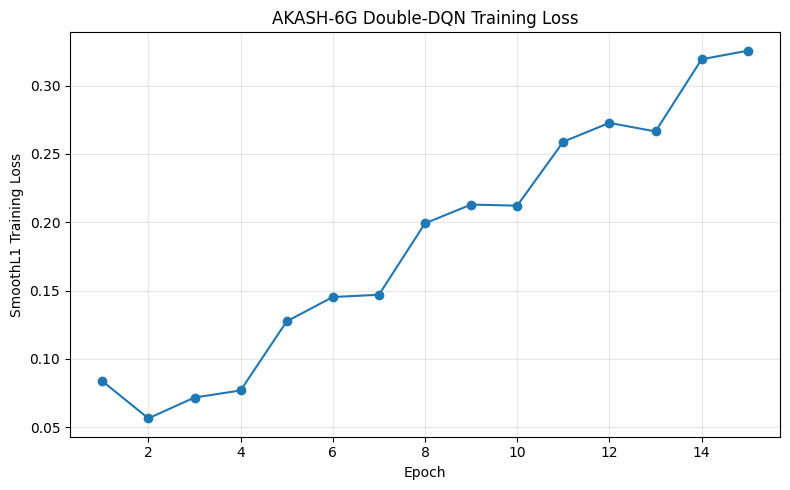

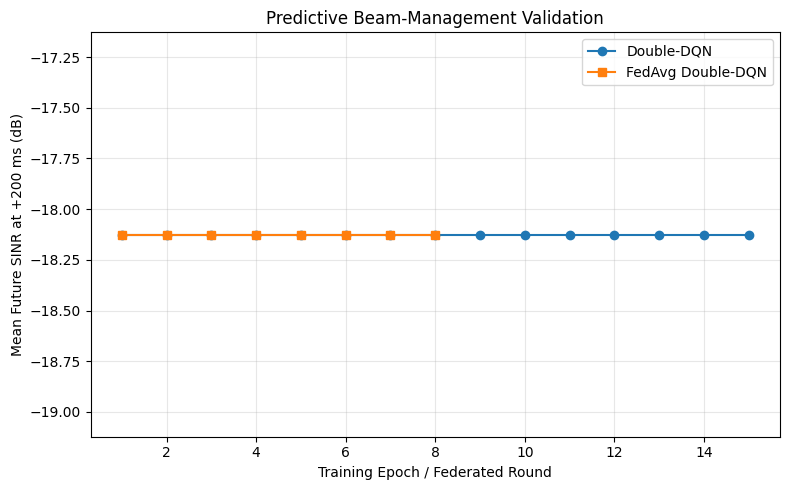

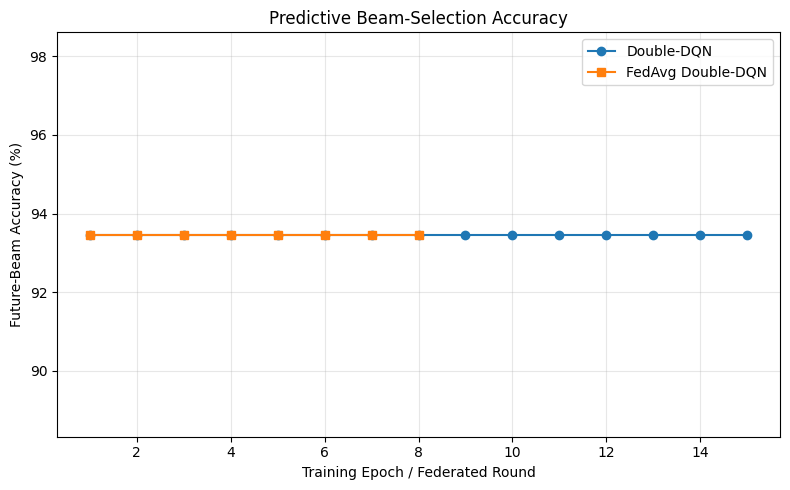

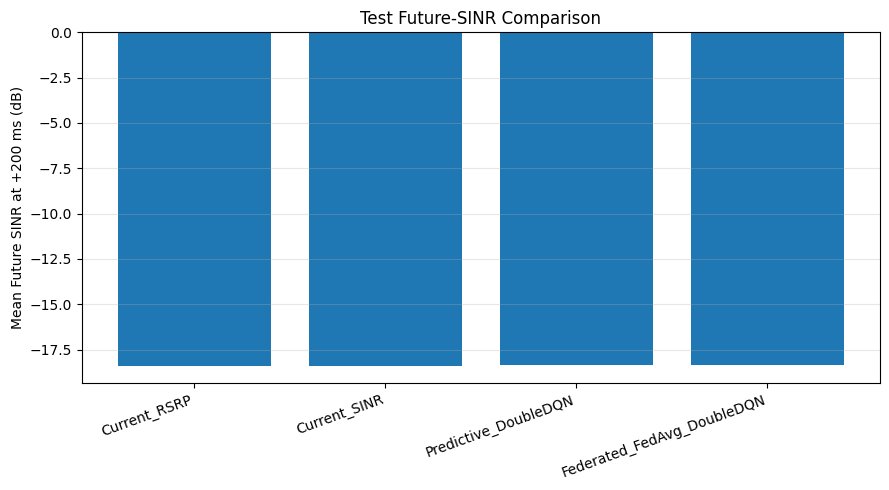

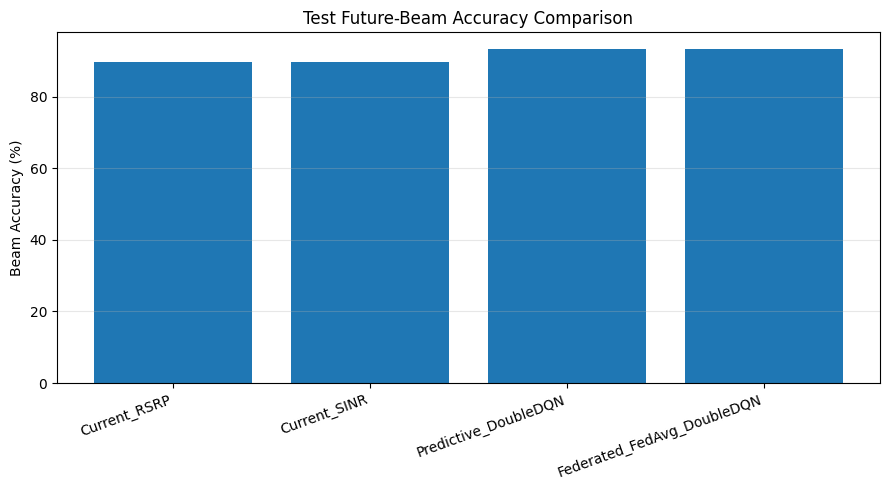


FINAL TEST RESULTS
                    Method  Future_SINR_dB  Beam_Accuracy_pct  Beam_Switch_Rate_pct  Mean_Reward
              Current_RSRP      -18.421789          89.595506              8.137828     3.398201
              Current_SINR      -18.423500          89.543071              8.202247     3.394977
      Predictive_DoubleDQN      -18.324329          93.285393              0.000000     3.805236
Federated_FedAvg_DoubleDQN      -18.324329          93.285393              0.000000     3.805236

Hard-case analysis:
                    Method  Hard_Cases_Current_vs_Future  Hard_Case_Accuracy_pct
      Predictive_DoubleDQN                          4482                     0.0
Federated_FedAvg_DoubleDQN                          4482                     0.0

All outputs saved to: /content/AKASH6G_AKASH6G_FINAL_RESULTS
Total runtime: 9.51 min
READY: physics audit -> predictive Double-DQN -> optional FedAvg


In [62]:
import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

# Colab path. For Kaggle, change this to the Kaggle input path.
DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv"
)

# Also support the filename used in some Colab uploads.
ALTERNATE_DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
)

OUTPUT_DIR = Path("/content/AKASH6G_AKASH6G_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Physical / temporal configuration
N_BEAMS = 4
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

# Dataset structure
ROWS_PER_UE = 100
VALID_ROWS_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_ROWS_PER_UE - 1

# Train / validation / test split is by UE, never by row.
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Double-DQN
GAMMA = 0.95
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
EPOCHS = 15
REPLAY_CAPACITY = 350_000
MIN_REPLAY = 5_000
TARGET_UPDATE_STEPS = 1_000
GRAD_CLIP = 5.0

# Exploration is used during optimization only.
EPS_START = 1.0
EPS_END = 0.05

# Reward design
SINR_THRESHOLD_DB = 5.0
W_THROUGHPUT = 1.0
W_SWITCH = 0.5
W_FAILURE = 2.0
HANDOVER_COST = 10.0
FAILURE_COST = 50.0

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 8
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 1
FED_BATCH_SIZE = 512
FED_LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]
RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]

REQUIRED_COLS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    *CONTINUOUS_STATE_COLS,
    *SINR_COLS,
    *RSRP_COLS,
]


# ================================================================
# 3. UTILITY FUNCTIONS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    """Convert beam0/beam1/... or numeric labels to integer 0..3."""
    if pd.isna(x):
        return -1

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s.replace("beam", "", 1)
        try:
            return int(float(s))
        except ValueError:
            return -1

    try:
        return int(float(x))
    except (TypeError, ValueError):
        return -1


def convert_beam_column(series):
    return series.map(beam_to_int).astype(np.int16)


def resolve_dataset_path():
    if DATASET_PATH.exists():
        return DATASET_PATH
    if ALTERNATE_DATASET_PATH.exists():
        return ALTERNATE_DATASET_PATH
    raise FileNotFoundError(
        "\nDataset not found.\n"
        f"Tried:\n  {DATASET_PATH}\n  {ALTERNATE_DATASET_PATH}\n"
        "\nUpload the corrected physical CSV to Colab or change DATASET_PATH."
    )


def save_json(path, obj):
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        return str(v)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=convert)


# ================================================================
# 4. LOAD + NORMALIZE LABELS
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path)

    # Normalize beam columns immediately.
    for col in ["Current_Beam", "Optimal_Beam", "Future_Beam"]:
        df[col] = convert_beam_column(df[col])

    # Ensure flag is numeric.
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"], errors="coerce"
    ).fillna(0).astype(np.int8)

    # Numeric conversion for all physical columns.
    for col in CONTINUOUS_STATE_COLS + ["UE_ID", "Time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    log(f"Loaded shape: {df.shape}")
    return df, path


# ================================================================
# 5. PHYSICAL DATASET AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(df["UE_ID"].nunique())

    log(f"Rows       : {len(df):,}")
    log(f"Columns    : {len(df.columns)}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing:,}")
    log(f"Duplicates : {duplicates:,}")

    if missing or duplicates:
        raise ValueError("Dataset audit failed: missing values or duplicate rows.")

    # Valid beam labels.
    for col in ["Current_Beam", "Optimal_Beam"]:
        if not df[col].between(0, N_BEAMS - 1).all():
            raise ValueError(f"Invalid values in {col}.")

    # Time spacing and per-UE ordering.
    bad_dt = 0
    bad_rows_per_ue = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            bad_rows_per_ue += 1
        dts = np.diff(g["Time_ms"].to_numpy(dtype=float))
        if len(dts) and np.max(np.abs(dts - DT_MS)) > 1e-9:
            bad_dt += 1

    log(f"UEs with wrong row count: {bad_rows_per_ue}")
    log(f"UEs with wrong time step : {bad_dt}")

    if bad_rows_per_ue or bad_dt:
        raise ValueError("Temporal dataset audit failed.")

    # Current beam linkage.
    current_rsrp = df[RSRP_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]
    current_sinr = df[SINR_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]

    rsrp_err = np.max(np.abs(current_rsrp - df["Current_RSRP_dBm"].to_numpy()))
    sinr_err = np.max(np.abs(current_sinr - df["Current_SINR_dB"].to_numpy()))

    # Optimal beam should be the physical strongest-beam decision.
    rsrp_argmax = df[RSRP_COLS].to_numpy().argmax(axis=1)
    sinr_argmax = df[SINR_COLS].to_numpy().argmax(axis=1)

    opt = df["Optimal_Beam"].to_numpy()

    opt_rsrp_acc = float(np.mean(rsrp_argmax == opt))
    opt_sinr_acc = float(np.mean(sinr_argmax == opt))

    log(f"Current-RSRP linkage max error: {rsrp_err:.6g} dB")
    log(f"Current-SINR linkage max error: {sinr_err:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {100*opt_rsrp_acc:.3f}%")
    log(f"Optimal vs SINR argmax       : {100*opt_sinr_acc:.3f}%")

    # Future target verification.
    future_mismatch = 0
    flag_mismatch = 0
    valid_rows = 0

    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(VALID_ROWS_PER_UE):
            expected = int(g.loc[t + H_STEPS, "Optimal_Beam"])
            actual = int(g.loc[t, "Future_Beam"])
            if expected != actual:
                future_mismatch += 1

            if int(g.loc[t, "Valid_Future_Target"]) != 1:
                flag_mismatch += 1
            valid_rows += 1

        for t in range(VALID_ROWS_PER_UE, ROWS_PER_UE):
            if int(g.loc[t, "Valid_Future_Target"]) != 0:
                flag_mismatch += 1

    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {flag_mismatch}")
    log(f"Valid predictive rows        : {valid_rows:,}")

    if future_mismatch or flag_mismatch:
        raise ValueError("Future-target audit failed.")

    # Current beam should equal previous optimal beam after the first sample
    # in the supplied physical generator.
    current_prev_mismatch = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(1, len(g)):
            if int(g.loc[t, "Current_Beam"]) != int(g.loc[t - 1, "Optimal_Beam"]):
                current_prev_mismatch += 1

    log(f"Current-beam temporal linkage : {current_prev_mismatch}")

    # This is diagnostic, not a hard failure. If RSRP and SINR rank every beam
    # identically, the physics model gives the DQN little independent SINR
    # decision structure. We explicitly report it rather than hiding it.
    rank_agreement = float(np.mean(rsrp_argmax == sinr_argmax))
    log(f"RSRP-argmax == SINR-argmax    : {100*rank_agreement:.3f}%")

    if rank_agreement > 0.999:
        log("WARNING: RSRP and SINR produce essentially identical beam rankings.")
        log("This is a physical-model limitation, not a Python training error.")
        log("For the paper, improve the MATLAB interference model if independent")
        log("RSRP-vs-SINR beam decisions are required.")

    audit = {
        "rows": len(df),
        "columns": len(df.columns),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "rows_per_ue": ROWS_PER_UE,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "valid_predictive_rows": valid_rows,
        "current_rsrp_max_error_db": float(rsrp_err),
        "current_sinr_max_error_db": float(sinr_err),
        "optimal_vs_rsrp_argmax": opt_rsrp_acc,
        "optimal_vs_sinr_argmax": opt_sinr_acc,
        "rsrp_sinr_argmax_agreement": rank_agreement,
    }

    return audit


# ================================================================
# 6. STATE CONSTRUCTION
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING 19-D STATES")

    # Sort once. All later transition logic is per UE.
    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    train_mask = df["UE_ID"].isin(train_ues)
    train_rows = df.loc[train_mask]

    X_train_raw = train_rows[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)

    mean = X_train_raw.mean(axis=0)
    std = X_train_raw.std(axis=0)
    std[std < 1e-8] = 1.0

    df_state = df[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)
    df_state = (df_state - mean) / std

    # One-hot current beam: 4 additional features.
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([df_state, onehot], axis=1).astype(np.float32)

    assert state.shape[1] == 19

    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    return df, state, mean, std


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique())
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. COUNTERFACTUAL OFFLINE RL TRANSITIONS
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """
    Compute reward for ALL 4 possible beam actions.

    Crucially:
      - Future_Beam is NOT used.
      - The action is not chosen from the future target.
      - The future SINR vector is used to score every possible action.
      - A constant failure penalty is centered out for optimization,
        because it is action-independent when all four future SINRs are
        below threshold.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)

    throughput = np.log2(1.0 + np.power(10.0, sinr / 10.0))

    switch_penalty = (np.arange(N_BEAMS) != int(previous_beam)).astype(np.float32)
    failure_penalty = (sinr < SINR_THRESHOLD_DB).astype(np.float32)

    raw = (
        W_THROUGHPUT * throughput
        - W_SWITCH * HANDOVER_COST * switch_penalty
        - W_FAILURE * FAILURE_COST * failure_penalty
    )

    # Per-state centering preserves action ordering but improves numerical
    # conditioning when the failure penalty is identical for every action.
    centered = raw - np.mean(raw)

    return raw.astype(np.float32), centered.astype(np.float32)


def build_transition_pool(df, state, ue_ids):
    """
    Build 4 counterfactual actions for every valid decision state.

    Number of states per UE = 89.
    Number of transitions per UE = 89 * 4 = 356.

    The reward for action a is computed using the actual physical beam-a
    SINR at t+200 ms.
    """
    log(f"Building transition pool for {len(ue_ids)} UEs...")

    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    raw_rewards = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            # State at t and next observed state at t+1.
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            # True future physical SINR vector at t+200 ms.
            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[SINR_COLS].to_numpy(dtype=np.float32)

            previous_beam = int(g.iloc[t]["Current_Beam"])

            raw_r, centered_r = reward_vector(future_sinr, previous_beam)

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(centered_r[a])
                raw_rewards.append(raw_r[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(int(future_row["Optimal_Beam"]))

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    RAW_R = np.asarray(raw_rewards, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)

    log(f"Transitions: {len(X):,}")
    log(
        f"Pool shapes: states={X.shape}, rewards={R.shape}, "
        f"raw_rewards={RAW_R.shape}, future_sinr={FS.shape}"
    )

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "raw_rewards": RAW_R,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
    }


# ================================================================
# 9. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        # Deterministic subset if pool exceeds capacity.
        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(len(pool["states"]), size=n, replace=False)
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.from_numpy(self.states[idx]),
            torch.from_numpy(self.actions[idx]),
            torch.from_numpy(self.rewards[idx]),
            torch.from_numpy(self.next_states[idx]),
            torch.from_numpy(self.dones[idx]),
        )


# ================================================================
# 10. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    def __init__(self, state_dim=19, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_actions(model, X):
    model.eval()
    out = []
    batch_size = 8192

    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        q = model(xb)
        out.append(q.argmax(dim=1).cpu().numpy())

    return np.concatenate(out).astype(np.int64)


# ================================================================
# 11. DOUBLE-DQN TRAINING
# ================================================================

def epsilon_at_step(step, total_steps):
    if total_steps <= 1:
        return EPS_END
    # Exponential schedule that reaches EPS_END at final step.
    frac = step / float(total_steps - 1)
    return float(EPS_START * ((EPS_END / EPS_START) ** frac))


def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError("Replay buffer is too small for training.")

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(1, replay.size // BATCH_SIZE)
    total_steps = batches_per_epoch * EPOCHS

    history = []
    global_step = 0
    best_val_reward = -np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)

            states = states.to(DEVICE)
            actions = actions.to(DEVICE)
            rewards = rewards.to(DEVICE)
            next_states = next_states.to(DEVICE)
            dones = dones.to(DEVICE)

            # Double-DQN:
            # online network chooses next action
            # target network evaluates that chosen action
            q_values = model(states)
            q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(dim=1)
                next_q = target(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)

                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q_selected, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        # Validation on the full counterfactual validation pool.
        val_metrics = evaluate_policy(model, val_pool)

        mean_loss = float(np.mean(losses))
        eps = epsilon_at_step(
            min(global_step, total_steps - 1), total_steps
        )

        row = {
            "epoch": epoch,
            "loss": mean_loss,
            "val_reward": val_metrics["mean_reward"],
            "val_raw_reward": val_metrics["mean_raw_reward"],
            "val_future_sinr_db": val_metrics["future_sinr_db"],
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "val_switch_rate_pct": val_metrics["switch_rate_pct"],
            "epsilon": eps,
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {mean_loss:.5f} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Eps {eps:.4f}"
        )

        if val_metrics["mean_reward"] > best_val_reward:
            best_val_reward = val_metrics["mean_reward"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Training time: {elapsed/60:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 12. POLICY EVALUATION
# ================================================================

@torch.no_grad()
def evaluate_policy(model, pool):
    """Evaluate one learned beam decision per unique physical state.

    Pool layout is:
        states      = (N*4, 19)
        rewards     = (N*4,)
        raw_rewards = (N*4,)
        future_sinr = (N*4, 4)

    Thus raw_rewards reshapes to (N,4), while future_sinr reshapes
    to (N,4,4) and then keeps the first copy of each state.
    """
    model.eval()

    total = len(pool["states"])
    if total == 0:
        raise ValueError("Cannot evaluate an empty pool.")
    if total % N_BEAMS != 0:
        raise ValueError(f"Pool size {total} is not divisible by {N_BEAMS}.")

    n_states = total // N_BEAMS

    if pool["raw_rewards"].shape != (total,):
        raise ValueError(
            f"raw_rewards shape {pool['raw_rewards'].shape} is invalid; expected ({total},)."
        )
    if pool["future_sinr"].shape != (total, N_BEAMS):
        raise ValueError(
            f"future_sinr shape {pool['future_sinr'].shape} is invalid; "
            f"expected ({total}, {N_BEAMS})."
        )
    if len(pool["current_beam"]) != total or len(pool["future_optimal"]) != total:
        raise ValueError("Beam metadata length does not match the transition pool.")

    unique_states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states, N_BEAMS, N_BEAMS
    )[:, 0, :]

    raw_rewards = pool["raw_rewards"].reshape(
        n_states, N_BEAMS
    )

    predicted = predict_actions(model, unique_states)

    chosen_sinr = future_sinr[np.arange(n_states), predicted]
    chosen_raw = raw_rewards[np.arange(n_states), predicted]

    centered = np.empty(n_states, dtype=np.float32)
    for i in range(n_states):
        _, c = reward_vector(future_sinr[i], int(current[i]))
        centered[i] = c[predicted[i]]

    accuracy = float(np.mean(predicted == optimal) * 100.0)
    switch_rate = float(np.mean(predicted != current) * 100.0)

    hard = current != optimal
    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard) else float("nan")
    )

    return {
        "mean_reward": float(centered.mean()),
        "mean_raw_reward": float(chosen_raw.mean()),
        "future_sinr_db": float(chosen_sinr.mean()),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(hard.sum()),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
    }


# ================================================================
# 13. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    future_sinr = pool["future_sinr"][::N_BEAMS]
    current_beam = pool["current_beam"][::N_BEAMS]
    future_optimal = pool["future_optimal"][::N_BEAMS]

    # Baseline A: choose strongest current RSRP/SINR.
    # Since current SINR is directly available in the state, the physical
    # beam-specific SINR columns are recovered from the first state block.
    X = pool["states"][::N_BEAMS]

    # Continuous state positions 11..14 are beam SINR after the 11 first
    # continuous features? The state has 15 continuous features followed by
    # 4 one-hot current-beam values.
    current_sinr_norm = X[:, 11:15]

    # Normalization changes values but not ordering.
    current_sinr_choice = current_sinr_norm.argmax(axis=1)

    # RSRP positions 7..10.
    current_rsrp_norm = X[:, 7:11]
    current_rsrp_choice = current_rsrp_norm.argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", current_rsrp_choice),
        ("Current_SINR", current_sinr_choice),
    ]:
        chosen = future_sinr[np.arange(len(future_sinr)), choice]
        acc = np.mean(choice == future_optimal) * 100.0
        switch = np.mean(choice != current_beam) * 100.0

        raw = []
        centered = []
        for i in range(len(choice)):
            r, c = reward_vector(future_sinr[i], current_beam[i])
            raw.append(r[choice[i]])
            centered.append(c[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "accuracy_pct": float(acc),
            "switch_rate_pct": float(switch),
            "mean_reward": float(np.mean(centered)),
            "mean_raw_reward": float(np.mean(raw)),
            "actions": choice,
        }

    return results


# ================================================================
# 14. HARD-CASE ANALYSIS
# ================================================================

def hard_case_accuracy(pred, optimal, current):
    mask = current != optimal
    if not np.any(mask):
        return float("nan"), 0
    return float(np.mean(pred[mask] == optimal[mask]) * 100.0), int(mask.sum())


# ================================================================
# 15. FEDERATED AVERAGING
# ================================================================

def average_state_dicts(state_dicts, weights):
    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}
    for key in state_dicts[0].keys():
        value = None
        for sd, w in zip(state_dicts, weights):
            term = sd[key].float() * (float(w) / total)
            value = term if value is None else value + term
        global_state[key] = value

    return global_state


def local_train(client_model, pool, epochs=1, lr=1e-3, batch_size=512):
    client_model.train()
    optimizer = optim.Adam(client_model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()

    n = len(pool["states"])
    rng = np.random.default_rng(SEED + n)

    for _ in range(epochs):
        idx = rng.permutation(n)

        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            if len(b) < 2:
                continue

            states = torch.from_numpy(pool["states"][b]).to(DEVICE)
            actions = torch.from_numpy(pool["actions"][b]).to(DEVICE)
            rewards = torch.from_numpy(pool["rewards"][b]).to(DEVICE)
            next_states = torch.from_numpy(pool["next_states"][b]).to(DEVICE)
            dones = torch.from_numpy(pool["dones"][b]).to(DEVICE)

            q = client_model(states).gather(
                1, actions.unsqueeze(1)
            ).squeeze(1)

            with torch.no_grad():
                next_a = client_model(next_states).argmax(dim=1)
                next_q = client_model(next_states).gather(
                    1, next_a.unsqueeze(1)
                ).squeeze(1)
                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(client_model.parameters(), GRAD_CLIP)
            optimizer.step()

    return client_model


def federated_train(client_pools, val_pool, initial_model):
    """
    FedAvg:
      1. Copy global model to selected clients.
      2. Train locally.
      3. Weighted average model parameters.
      4. Broadcast new global model.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)
    global_model.load_state_dict(initial_model.state_dict())

    rng = np.random.default_rng(SEED)
    history = []

    n_clients = len(client_pools)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients, size=CLIENTS_PER_ROUND, replace=False
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())

            local_train(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(len(client_pools[int(client_id)]["states"]))

        new_state = average_state_dicts(local_states, weights)
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(global_model, val_pool)

        row = {
            "round": rnd,
            "val_reward": metrics["mean_reward"],
            "val_raw_reward": metrics["mean_raw_reward"],
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

    return global_model, pd.DataFrame(history)


# ================================================================
# 16. PREDICTION TABLE
# ================================================================

def make_prediction_table(pool, dqn_result, fed_result, test_ues):
    future_sinr = dqn_result["future_sinr_matrix"]
    current = dqn_result["current_beam"]
    optimal = dqn_result["future_optimal"]

    dqn_actions = dqn_result["predicted_actions"]
    fed_actions = (
        fed_result["predicted_actions"]
        if fed_result is not None else np.full_like(dqn_actions, -1)
    )

    rows = len(dqn_actions)

    out = pd.DataFrame({
        "Sample": np.arange(rows),
        "Current_Beam": current,
        "Future_Optimal_Beam": optimal,
        "DoubleDQN_Beam": dqn_actions,
        "FedAvg_DoubleDQN_Beam": fed_actions,
        "DQN_Correct": (dqn_actions == optimal).astype(int),
        "FedAvg_Correct": (fed_actions == optimal).astype(int),
        "DQN_Switch": (dqn_actions != current).astype(int),
        "FedAvg_Switch": (fed_actions != current).astype(int),
    })

    out["DQN_Future_SINR_dB"] = future_sinr[
        np.arange(rows), dqn_actions
    ]
    if fed_result is not None:
        out["FedAvg_Future_SINR_dB"] = future_sinr[
            np.arange(rows), fed_actions
        ]

    # Add UE IDs approximately through the test pool's state order.
    # Each state occurs exactly four times in the pool.
    out["Test_UE_Index"] = np.repeat(
        np.arange(len(test_ues)),
        TRANSITIONS_PER_UE
    )[:rows]
    out["UE_ID"] = out["Test_UE_Index"].map(
        {i: int(u) for i, u in enumerate(test_ues)}
    )

    return out


# ================================================================
# 17. PLOTS
# ================================================================

def save_plots(dqn_history, fed_history, comparison, output_dir):
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Training Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "01_training_loss.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "02_validation_future_sinr.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_accuracy_pct"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("Predictive Beam-Selection Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "03_validation_accuracy.png", dpi=300)
    plt.show()

    methods = list(comparison["Method"])
    values = list(comparison["Future_SINR_dB"])

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_test_future_sinr_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    values = list(comparison["Beam_Accuracy_pct"])

    plt.bar(methods, values)
    plt.ylabel("Beam Accuracy (%)")
    plt.title("Test Future-Beam Accuracy Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "05_test_accuracy_comparison.png", dpi=300)
    plt.show()


# ================================================================
# 18. MAIN EXPERIMENT
# ================================================================

def main():
    total_start = time.time()

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)

    # UE split must happen before normalization.
    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(df, train_ues)

    # Save normalization.
    np.save(OUTPUT_DIR / "train_state_mean.npy", mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    # Build pools.
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(df, state, train_ues)

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(df, state, val_ues)

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(df, state, test_ues)

    # Train central Double-DQN.
    dqn_model, dqn_history = train_double_dqn(
        train_pool, val_pool
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )
    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(dqn_model, test_pool)
    baseline = evaluate_baselines(test_pool)

    # Federated clients: split the training UEs into client groups.
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        # 10 clients by deterministic UE partitions.
        n_clients = max(CLIENTS_PER_ROUND, 10)
        client_ue_groups = np.array_split(train_ues, n_clients)

        client_pools = [
            build_transition_pool(df, state, group)
            for group in client_ue_groups
            if len(group) > 0
        ]

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
            dqn_model,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN.pt",
        )
        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(fed_model, test_pool)

    # ------------------------------------------------------------
    # Final test table
    # ------------------------------------------------------------
    rows = []

    rows.append({
        "Method": "Current_RSRP",
        "Future_SINR_dB": baseline["Current_RSRP"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_RSRP"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_RSRP"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_RSRP"]["mean_reward"],
    })

    rows.append({
        "Method": "Current_SINR",
        "Future_SINR_dB": baseline["Current_SINR"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_SINR"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_SINR"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_SINR"]["mean_reward"],
    })

    rows.append({
        "Method": "Predictive_DoubleDQN",
        "Future_SINR_dB": dqn_test["future_sinr_db"],
        "Beam_Accuracy_pct": dqn_test["accuracy_pct"],
        "Beam_Switch_Rate_pct": dqn_test["switch_rate_pct"],
        "Mean_Reward": dqn_test["mean_reward"],
    })

    if fed_test is not None:
        rows.append({
            "Method": "Federated_FedAvg_DoubleDQN",
            "Future_SINR_dB": fed_test["future_sinr_db"],
            "Beam_Accuracy_pct": fed_test["accuracy_pct"],
            "Beam_Switch_Rate_pct": fed_test["switch_rate_pct"],
            "Mean_Reward": fed_test["mean_reward"],
        })

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "AKASH6G_FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Hard-case analysis
    # ------------------------------------------------------------
    dqn_hard_acc, n_hard = hard_case_accuracy(
        dqn_test["predicted_actions"],
        dqn_test["future_optimal"],
        dqn_test["current_beam"],
    )

    if fed_test is not None:
        fed_hard_acc, _ = hard_case_accuracy(
            fed_test["predicted_actions"],
            fed_test["future_optimal"],
            fed_test["current_beam"],
        )
    else:
        fed_hard_acc = float("nan")

    hard_case = pd.DataFrame([{
        "Method": "Predictive_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": dqn_hard_acc,
    }, {
        "Method": "Federated_FedAvg_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": fed_hard_acc,
    }])

    hard_case.to_csv(
        OUTPUT_DIR / "AKASH6G_HARD_CASE_ANALYSIS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction export
    # ------------------------------------------------------------
    pred_table = make_prediction_table(
        test_pool,
        dqn_test,
        fed_test,
        test_ues,
    )
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_TEST_PREDICTIONS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Final audit / config
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_rows_per_ue": VALID_ROWS_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "state_dimension": 19,
        "train_ues": len(train_ues),
        "val_ues": len(val_ues),
        "test_ues": len(test_ues),
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "replay_capacity": REPLAY_CAPACITY,
        "reward": {
            "sinr_threshold_db": SINR_THRESHOLD_DB,
            "w_throughput": W_THROUGHPUT,
            "w_switch": W_SWITCH,
            "w_failure": W_FAILURE,
            "handover_cost": HANDOVER_COST,
            "failure_cost": FAILURE_COST,
        },
        "federated": {
            "enabled": RUN_FEDERATED,
            "rounds": FED_ROUNDS,
            "clients_per_round": CLIENTS_PER_ROUND,
            "local_epochs": LOCAL_EPOCHS,
        },
        "methodology": (
            "physics-backed counterfactual offline/dataset-driven "
            "Double-DQN with optional FedAvg"
        ),
    }

    save_json(OUTPUT_DIR / "AKASH6G_FINAL_CONFIG.json", config)
    save_json(OUTPUT_DIR / "AKASH6G_PHYSICAL_AUDIT.json", audit)

    with open(
        OUTPUT_DIR / "AKASH6G_FINAL_AUDIT.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write("PROJECT AKASH-6G FINAL EXPERIMENT AUDIT\n")
        f.write("=" * 72 + "\n\n")
        f.write(f"Dataset: {dataset_path}\n")
        f.write(f"Rows: {len(df):,}\n")
        f.write(f"UEs: {df['UE_ID'].nunique():,}\n")
        f.write(f"State dimension: 19\n")
        f.write(f"Prediction horizon: {PREDICTION_HORIZON_MS} ms\n")
        f.write(f"Prediction steps: {H_STEPS}\n")
        f.write("\nIMPORTANT:\n")
        f.write(
            "This experiment is dataset-driven/counterfactual offline RL. "
            "The fixed dataset does not contain action-dependent next-state "
            "transitions.\n"
        )
        f.write(
            "Future_Beam is never used to choose the replay action. "
            "All four actions are evaluated using the future physical SINR "
            "vector, then Double-DQN learns from the resulting action pool.\n"
        )
        f.write(
            "\nDo not describe the generated CSV as measured satellite data. "
            "It is a physics-based simulation dataset.\n"
        )

    # ------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        OUTPUT_DIR,
    )

    # ------------------------------------------------------------
    # Final console output
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(comparison.to_string(index=False))

    log("\nHard-case analysis:")
    print(hard_case.to_string(index=False))

    log(f"\nAll outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time()-total_start)/60:.2f} min")
    log("READY: physics audit -> predictive Double-DQN -> optional FedAvg")


if __name__ == "__main__":
    main()
